# **Used Cars Price Prediction**

## **Problem Definition**

### **The Context:**

 - In Indian markets, pre-owned cars are selling more than new cars (4 million vs 3.6 million cars). The market is observing a reduction in new car sales, suggesting that customers prefer to purchase pre-owned cars over new cars. Cars4U is a tech start-up that wants to sell cars, both new and used. Pricing new cars is relatively straighforward, but pricing used cars can be difficult, as it depends on several factors like mileage, brand, model, year etc.

### **The objective:**

 - The goal is to devise a prediction model that can effectively predict the price of used cars.

### **The key questions:**

- Which features have the greatest impact on used car prices?
- How well does the regression model perform on unseen data?
- Can we improve the model performance?

### **The problem formulation**:

- Use regression modeling to build a pricing model that effectively predicts the price of used cars, using the top features that influence the price. This could be linear or non-linear regression modeling, and we will iteratively improve the model performance by evaluating key metrics and adjusting the features used if needed.

### **Data Dictionary**

**S.No.** : Serial Number

**Name** : Name of the car which includes Brand name and Model name

**Location** : The location in which the car is being sold or is available for purchase (Cities)

**Year** : Manufacturing year of the car

**Kilometers_driven** : The total kilometers driven in the car by the previous owner(s) in KM

**Fuel_Type** : The type of fuel used by the car (Petrol, Diesel, Electric, CNG, LPG)

**Transmission** : The type of transmission used by the car (Automatic / Manual)

**Owner** : Type of ownership

**Mileage** : The standard mileage offered by the car company in kmpl or km/kg

**Engine** : The displacement volume of the engine in CC

**Power** : The maximum power of the engine in bhp

**Seats** : The number of seats in the car

**New_Price** : The price of a new car of the same model in INR 100,000

**Price** : The price of the used car in INR 100,000 (**Target Variable**)

### **Loading libraries**

In [ ]:
#Libs to tidy data
import numpy as np
import pandas as pd

#Libs for visualisation
import seaborn as sb
import matplotlib.pyplot as plt
%matplotlib inline

#Libs for regression modeling
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")


### **Let us load the data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#Load the datset
cars = pd.read_csv('/content/drive/MyDrive/MIT Capstone Project/used_cars.csv')
data = cars.copy()

Mounted at /content/drive


## Data Overview

- Observations
- Sanity checks

In [ ]:
#Check the first 5 rows
data.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,8.61,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,NaN,17.74


In [ ]:
#Check the types for each col
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              7253 non-null   int64  
 1   Name               7253 non-null   object 
 2   Location           7253 non-null   object 
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   object 
 6   Transmission       7253 non-null   object 
 7   Owner_Type         7253 non-null   object 
 8   Mileage            7251 non-null   float64
 9   Engine             7207 non-null   float64
 10  Power              7078 non-null   float64
 11  Seats              7200 non-null   float64
 12  New_price          1006 non-null   float64
 13  Price              6019 non-null   float64
dtypes: float64(6), int64(3), object(5)
memory usage: 793.4+ KB


In [ ]:
#Check for NA values
data.isna().sum()

,0
S.No.,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,2
Engine,46


Observations:

- The dataset has 7253 rows and 14 columns.
- There are missing values in Engine, Power, Seats, New_price and Price columns.
- The dataset is a mixture of categorical and numerical values.

## **Exploratory Data Analysis**

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions:**

1. What is the summary statistics of the data? Explore summary statistics for numerical variables and the categorical variables
2. Find out number of unique observations in each category of categorical columns? Write your findings/observations/insights
3. Check the extreme values in different columns of the given data and write down the observtions? Remove the data where the values are un-realistic

In [ ]:
#Check statistics for numerical variables
data.describe()

,S.No.,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,New_price,Price
count,7253.000000,7253.000000,7.253000e+03,7251.000000,7207.000000,7078.000000,7200.000000,1006.000000,6019.000000
mean,3626.000000,2013.365366,5.869906e+04,18.141580,1616.573470,112.765214,5.280417,22.779692,9.479468
std,2093.905084,3.254421,8.442772e+04,4.562197,595.285137,53.493553,0.809277,27.759344,11.187917
min,0.000000,1996.000000,1.710000e+02,0.000000,72.000000,34.200000,2.000000,3.910000,0.440000
25%,1813.000000,2011.000000,3.400000e+04,15.170000,1198.000000,75.000000,5.000000,7.885000,3.500000
50%,3626.000000,2014.000000,5.341600e+04,18.160000,1493.000000,94.000000,5.000000,11.570000,5.640000
75%,5439.000000,2016.000000,7.300000e+04,21.100000,1968.000000,138.100000,5.000000,26.042500,9.950000
max,7252.000000,2019.000000,6.500000e+06,33.540000,5998.000000,616.000000,10.000000,375.000000,160.000000


In [ ]:
#Check statistics for categorical variables
data['Name'].value_counts()

,count
Name,
Mahindra XUV500 W8 2WD,55
Maruti Swift VDI,49
Maruti Swift Dzire VDI,42
Honda City 1.5 S MT,39
Maruti Swift VDI BSIV,37
...,...
Mercedes-Benz E-Class E240 V6 AT,1
Nissan Terrano XE 85 PS,1
Mahindra TUV 300 2015-2019 T8 AMT,1


In [ ]:
data['Location'].value_counts()

,count
Location,
Mumbai,949
Hyderabad,876
Coimbatore,772
Kochi,772
Pune,765
Delhi,660
Kolkata,654
Chennai,591
Jaipur,499


In [ ]:
data['Fuel_Type'].value_counts()

,count
Fuel_Type,
Diesel,3852
Petrol,3325
CNG,62
LPG,12
Electric,2


In [ ]:
data['Owner_Type'].value_counts()

,count
Owner_Type,
First,5952
Second,1152
Third,137
Fourth & Above,12


In [ ]:
data['Transmission'].value_counts()

,count
Transmission,
Manual,5204
Automatic,2049


Observations:

- The column 'Kilometers_Driven' shows us a large range from 1.710000e+02	to 6.500000e+06, with median of 5.869906e+04. It seems unlikely someone drove 6.500000e+06 kms, so this should be further investigated to see if it's an outlier.
- The column 'Seats' shows us that there are some cars with 10 seats, which seems unrealistic for modern cars. This can be further investigated.
- There are 2041 different types of cars by brand and model name in the dataset. However, some of these names may need cleaning up to aggregate similar names together.
- All of the cars in the dataset are second-hand, with most cars having one previous owner.

In [ ]:
#Investigate seats in cars
data['Seats'].value_counts()

data[data['Seats'] >= 9].head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price
814,814,Toyota Qualis FS B2,Pune,2004,77757,Diesel,Manual,Second,13.10,2446.0,75.0,10.0,NaN,3.50
917,917,Tata Sumo DX,Mumbai,2013,20000,Diesel,Manual,First,14.07,1978.0,83.1,10.0,NaN,5.25
1347,1347,Mahindra Scorpio LX BS IV,Bangalore,2007,74112,Diesel,Manual,First,12.05,2179.0,120.0,9.0,NaN,4.10
1907,1907,Toyota Qualis FS B3,Bangalore,2002,63000,Diesel,Manual,Third,13.10,2446.0,75.0,10.0,NaN,3.65
2267,2267,Toyota Qualis RS E2,Pune,2004,215750,Diesel,Manual,Second,0.00,2446.0,NaN,10.0,NaN,3.50


In [ ]:
#Investigate name of cars
temp_cars = data['Name'].value_counts()

temp_cars[temp_cars == 1]


,count
Name,
Hyundai Santro Xing XG AT eRLX Euro III,1
Hyundai EON LPG Era Plus Option,1
Toyota Corolla Altis GL,1
OpelCorsa 1.4Gsi,1
Toyota Innova 2.5 LE 2014 Diesel 8 Seater,1
...,...
Mercedes-Benz E-Class E240 V6 AT,1
Nissan Terrano XE 85 PS,1
Mahindra TUV 300 2015-2019 T8 AMT,1


In [ ]:
#Data tidy - remove S.No because this is the same as the number of rows present, adds no value
data_clean = data.drop('S.No.', axis = 1).copy()
data_clean.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_price,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,NaN,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,NaN,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,8.61,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,NaN,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,NaN,17.74


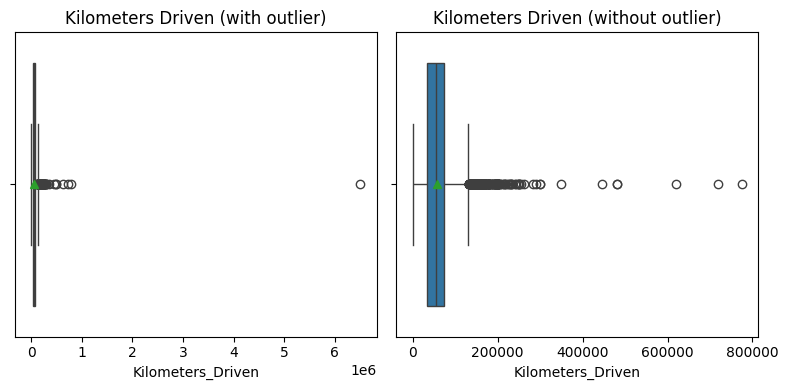

In [ ]:
#Data tidy - remove outlier in Kilometers driven col
data_clean.nlargest(10, 'Kilometers_Driven')
data_clean = data_clean[data_clean['Kilometers_Driven'] <= 1000000].copy()

#Plot before and after tidying
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

sb.boxplot(data, x='Kilometers_Driven', ax=axes[0], showmeans=True)
axes[0].set_title('Kilometers Driven (with outlier)')

sb.boxplot(data_clean, x='Kilometers_Driven', ax=axes[1], showmeans=True)
axes[1].set_title('Kilometers Driven (without outlier)')

plt.tight_layout()
plt.show()

Observations:

- After investigating the number of seats, it seems there are some real cars with 10 seats. Nothing will be done to change the values in this column.
- After investigating the name of cars, we can see that these are unique values, not caused by typos or difference in capital letters used. However, there are over 2000 car names that are unique and this would make prediction for price difficult. We can tidy this up later on, perhaps summarising the brand and model names.
- Serial Number column was removed, as this was just a list of the number of rows in the dataset and adds no further value.
- After investigating the kilometers driven, it seems there was an outlier present and this was removed before further analysis will be done.


## **Univariate Analysis**

**Questions:**

1. Do univariate analysis for numerical and categorical variables?
2. Check the distribution of the different variables? is the distributions skewed?
3. Do we need to do log_transformation, if so for what variables we need to do?
4. Perfoem the log_transformation(if needed) and write down your observations?

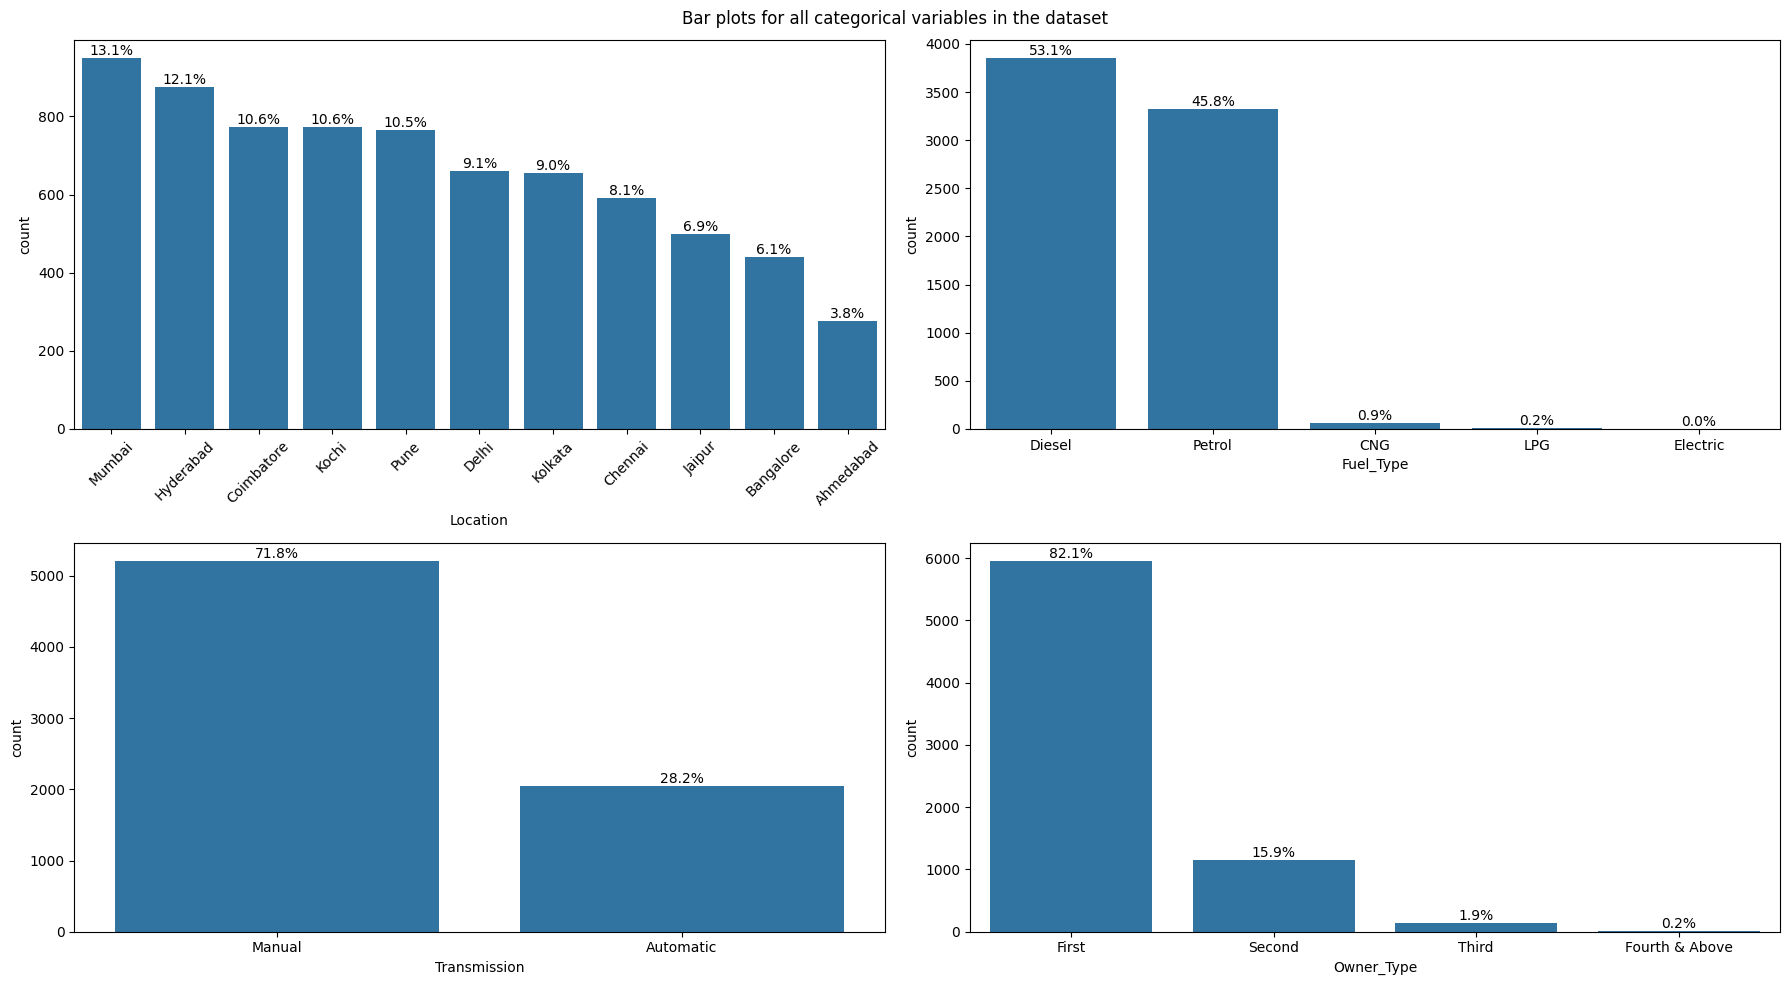

In [ ]:
# Univariate analysis - bar plots for each categorical variable
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Bar plots for all categorical variables in the dataset')

#Add percentages to the bars
def add_percentages(ax):
    total = len(data_clean)
    for bar in ax.patches:
        percentage = 100 * bar.get_height() / total
        ax.annotate(f'{percentage:.1f}%',
                    (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha='center', va='bottom',
                    fontsize=10)

#Plot each variable
sb.countplot(ax=axes[0, 0], x='Location', data=data_clean,
              order=data_clean['Location'].value_counts().index)
axes[0, 0].tick_params(axis='x', rotation=45)
add_percentages(axes[0, 0])


sb.countplot(ax=axes[0, 1], x='Fuel_Type', data=data_clean,
              order=data_clean['Fuel_Type'].value_counts().index)
add_percentages(axes[0, 1])


sb.countplot(ax=axes[1, 0], x='Transmission', data=data_clean,
              order=data_clean['Transmission'].value_counts().index)
add_percentages(axes[1, 0])


sb.countplot(ax=axes[1, 1], x='Owner_Type', data=data_clean,
              order=data_clean['Owner_Type'].value_counts().index)
add_percentages(axes[1, 1])

plt.tight_layout()
plt.show()

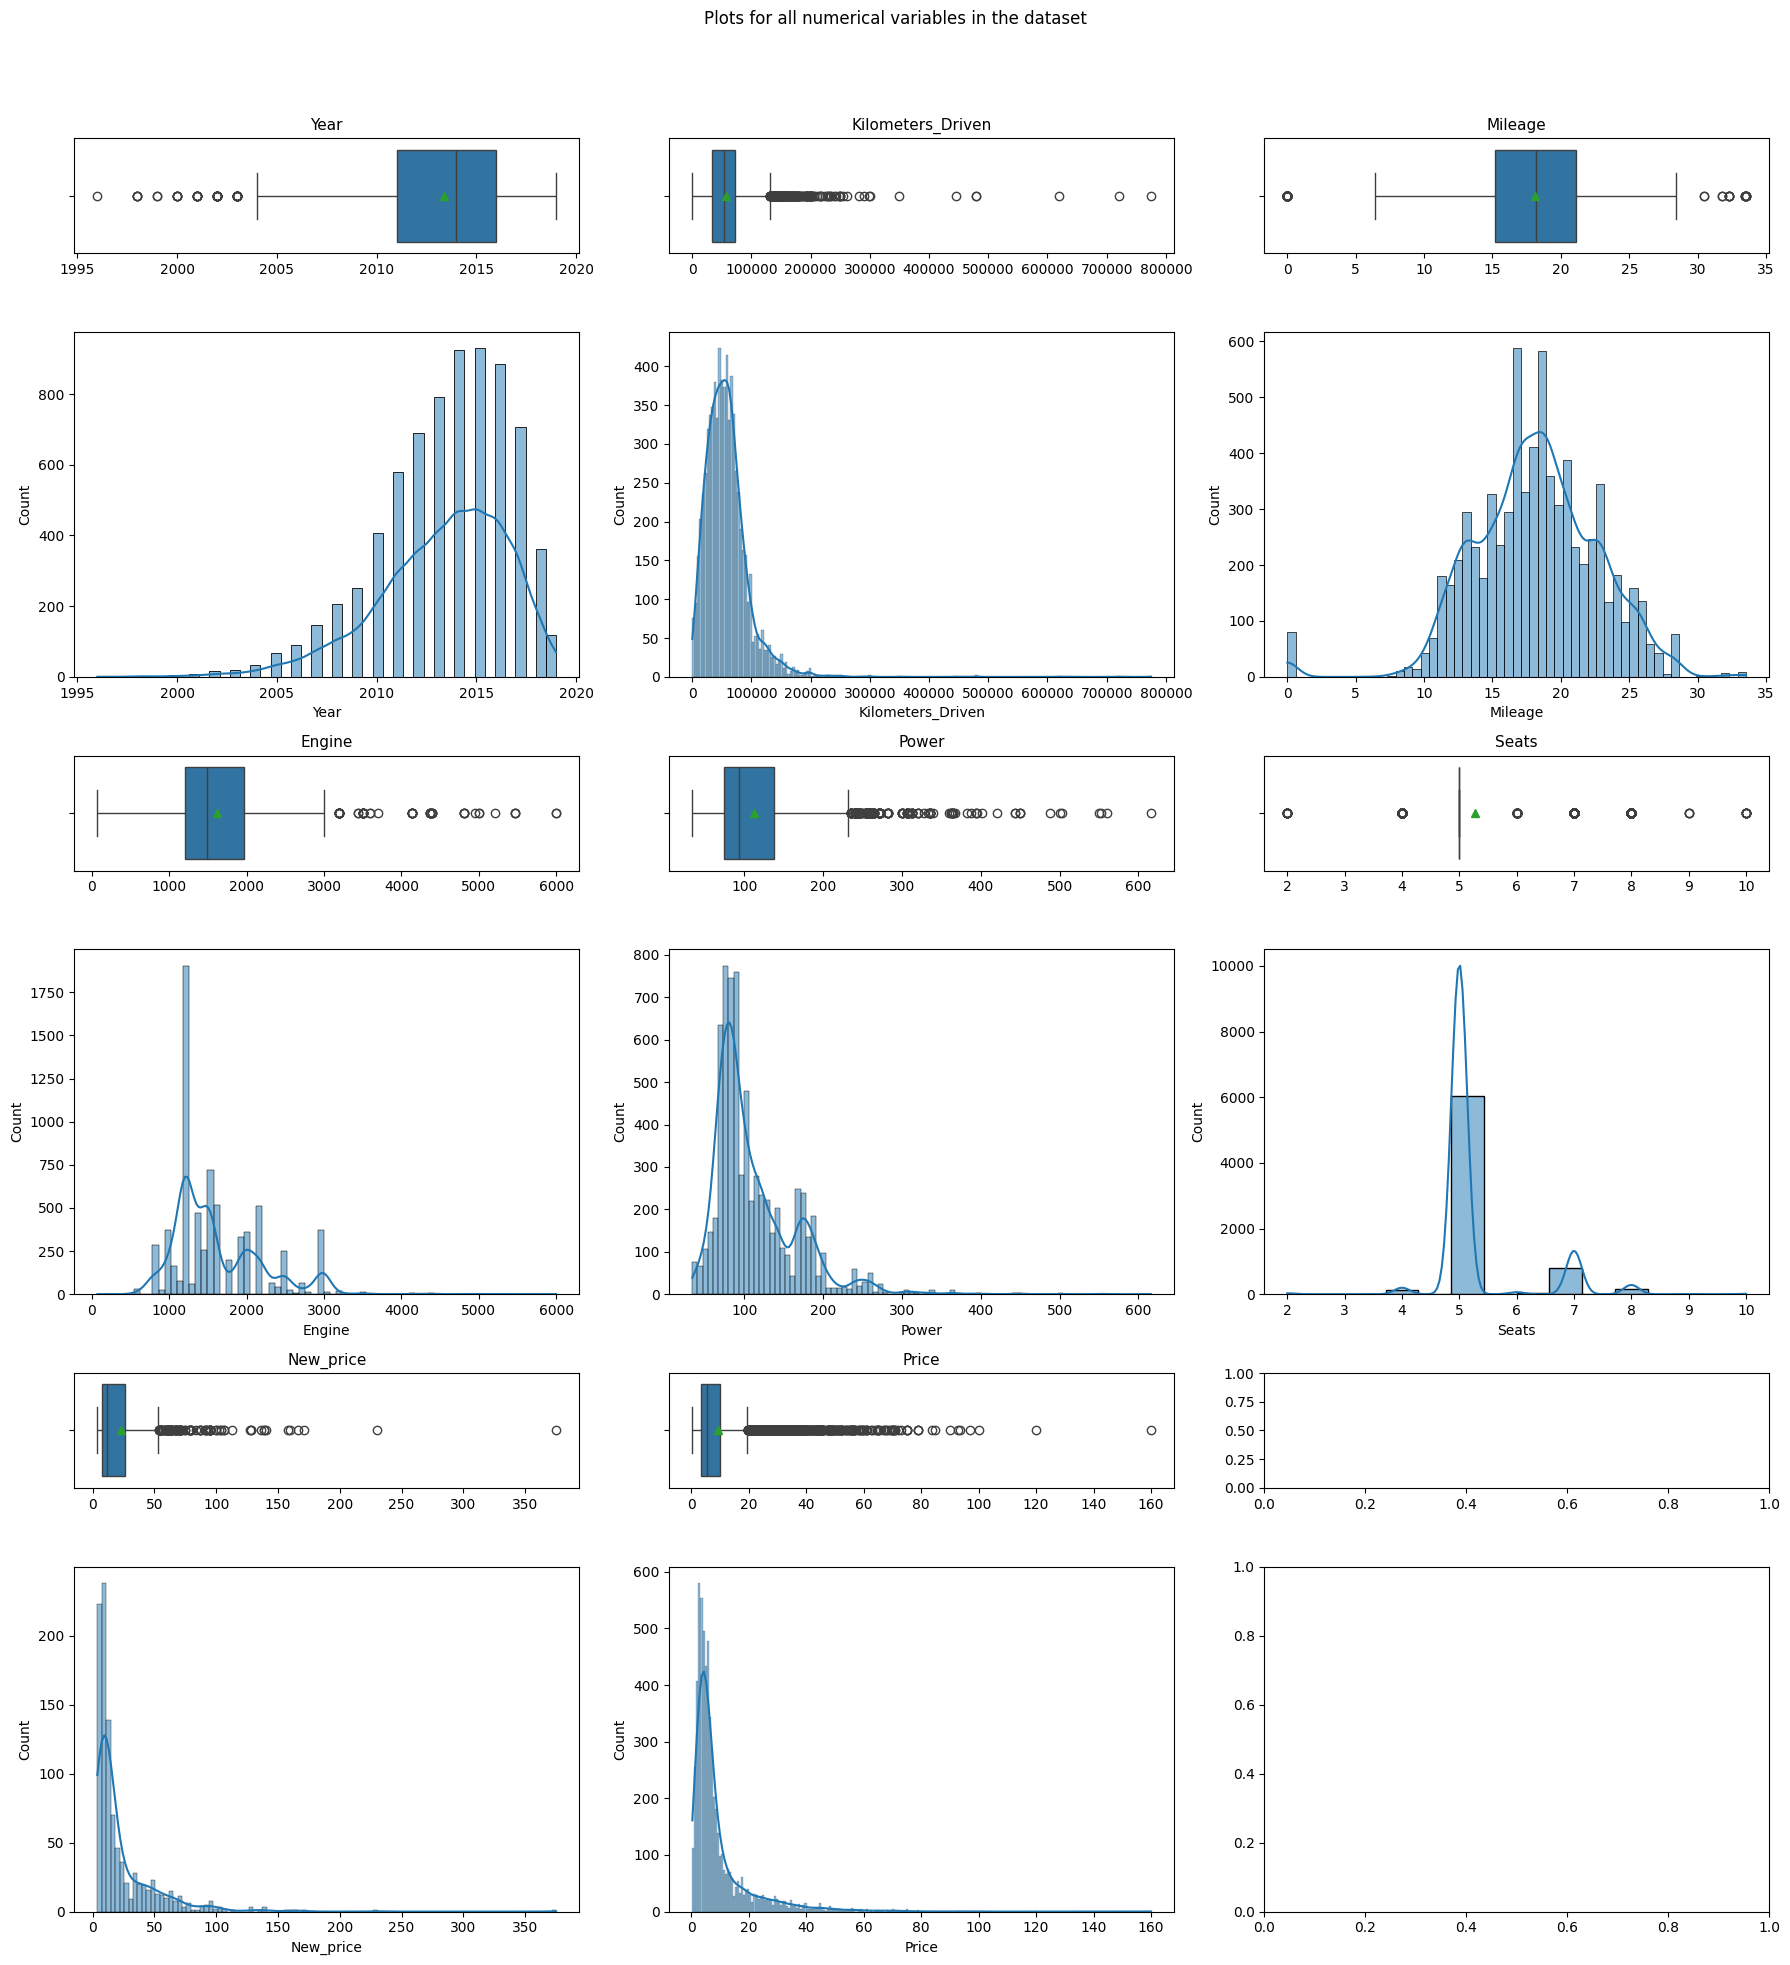

In [ ]:
#Univariate analysis - plot histogram for each numerical variable

#Define plot area and title
cols = data_clean.select_dtypes(exclude = 'object').columns
n_cols = 3
n_rows = 3
n_groups = 3
fig, axes = plt.subplots(nrows=n_groups * 2,
                         ncols=n_cols,
                         figsize=(18, 20),
                         gridspec_kw={"height_ratios": [1, 3] * n_groups})

#Loop through each col in dataset and plot
for i, col in enumerate(cols):
    row = (i // n_cols) * 2   # Boxplot row
    c = i % n_cols            # Column

    # Boxplot
    sb.boxplot(x=data_clean[col], ax=axes[row, c], showmeans=True)
    axes[row, c].set_title(col, fontsize=11)
    axes[row, c].set_xlabel("")

    # Histogram
    sb.histplot(data=data_clean, x=col, kde=True, ax=axes[row + 1, c])
    axes[row + 1, c].set_xlabel(col)

fig.suptitle("Plots for all numerical variables in the dataset")

#Adjust spacing between subplots for better visualisation
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

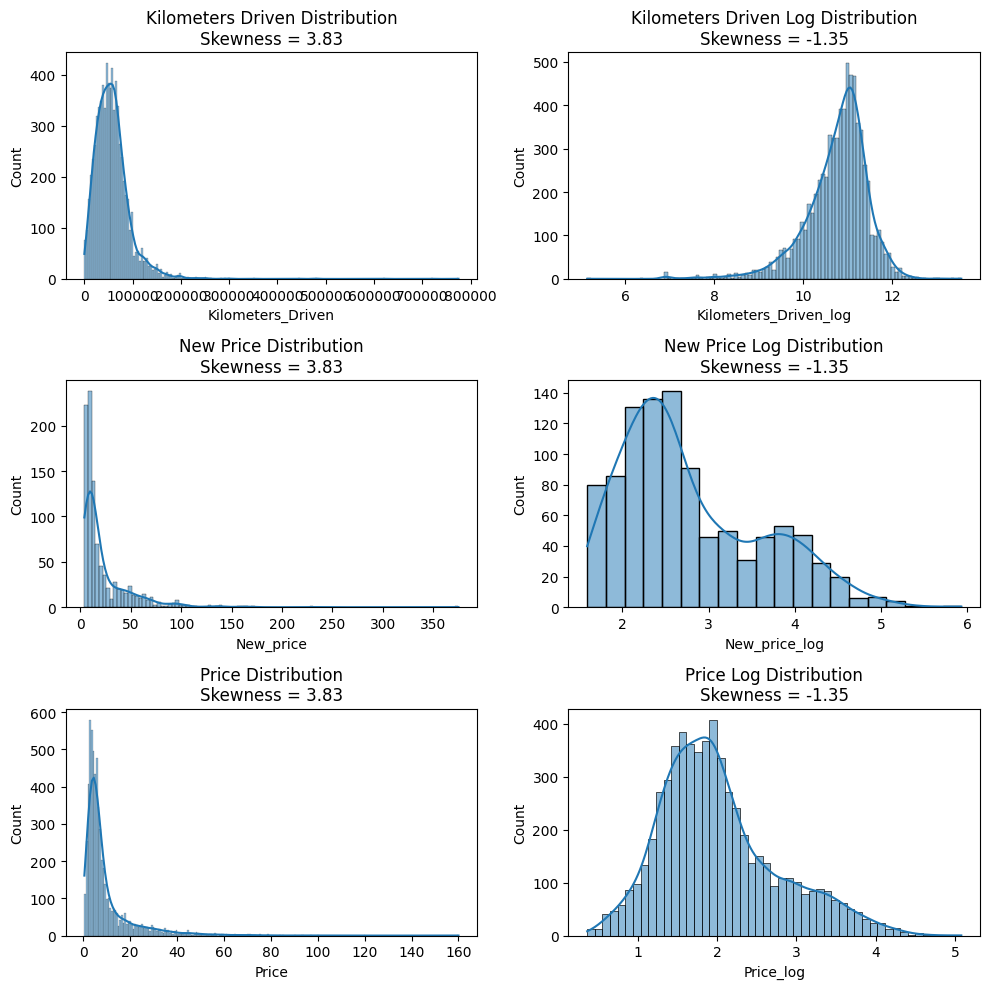

In [ ]:
#Log transform highly skewed variables - Kilometers_Driven, New_Price and Price
#If the skew value is >1, it is highly skewed and transforming it might help with model prediction

#Check skewness first
km_skew = data_clean['Kilometers_Driven'].skew()
np_skew = data_clean['New_price'].skew()
p_skew = data_clean['Price'].skew()

#Log transform - use log1p to account for zero values
data_clean['Kilometers_Driven_log'] = np.log(data_clean['Kilometers_Driven'])
data_clean['New_price_log'] = np.log1p(data_clean['New_price'])
data_clean['Price_log'] = np.log1p(data_clean['Price'])

#Check log transformed skewness
kmlog_skew = data_clean['Kilometers_Driven_log'].skew()
np_skew = data_clean['New_price_log'].skew()
p_skew = data_clean['Price_log'].skew()

#Plot before and after transformation
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
sb.histplot(data_clean, x='Kilometers_Driven', kde=True, ax=axes[0,0])
axes[0,0].set_title(f"Kilometers Driven Distribution\nSkewness = {km_skew:.2f}")

sb.histplot(data_clean, x='Kilometers_Driven_log', kde=True, ax=axes[0,1])
axes[0,1].set_title(f"Kilometers Driven Log Distribution\nSkewness = {kmlog_skew:.2f}")

sb.histplot(data_clean, x='New_price', kde=True, ax=axes[1,0])
axes[1,0].set_title(f"New Price Distribution\nSkewness = {km_skew:.2f}")

sb.histplot(data_clean, x='New_price_log', kde=True, ax=axes[1,1])
axes[1,1].set_title(f"New Price Log Distribution\nSkewness = {kmlog_skew:.2f}")

sb.histplot(data_clean, x='Price', kde=True, ax=axes[2,0])
axes[2,0].set_title(f"Price Distribution\nSkewness = {km_skew:.2f}")

sb.histplot(data_clean, x='Price_log', kde=True, ax=axes[2,1])
axes[2,1].set_title(f"Price Log Distribution\nSkewness = {kmlog_skew:.2f}")


plt.tight_layout()
plt.show()

Observations:

- The univariate analysis for categorical variables shows the distribution of Location, Fuel_Type, Transmission and Owner_Type clearly. We can observe that most cars in the dataset are either diesel or petrol, 72% are manual and 82% are first-owner cars. Most cars are from Mumbai or Hyderbad cities, with the fewest cars from Ahmedabad.
- When observing the numerical variables, we can observe Mileage and Seats have no skewed distribution, but most other variables are skewed.
- Engine and Power display multimodal distributions, while year displays slight left skewness, with fewer cars manufactured before 2005 being sold.
- Kilometers_Driven, New_price and Price are highly skewed to the right. To account for the high skewness observed we performed log transformation. This will help the regression model better predict used car prices.
- There are some outliers in the data, but nothing that skews the distribution so much that it requires cleaning up.

## **Bivariate Analysis**

**Questions:**

1. Plot a scatter plot for the log transformed values(if log_transformation done in previous steps)?
2. What can we infer form the correlation heatmap? Is there correlation between the dependent and independent variables?
3. Plot a box plot for target variable and categorical variable 'Location' and write your observations?

<Axes: >

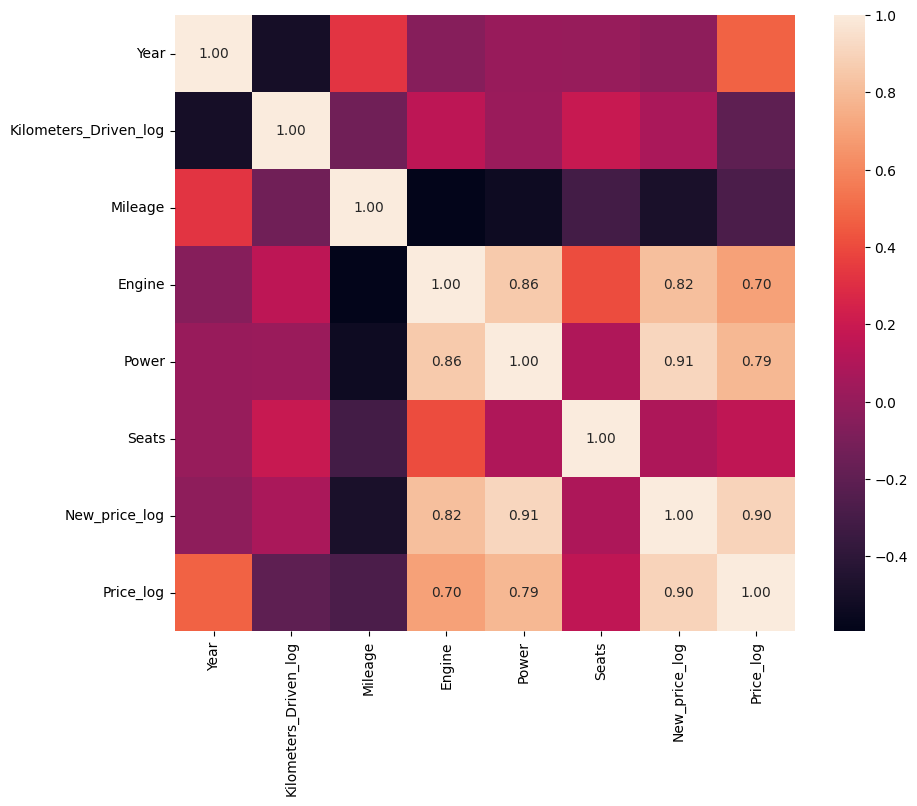

In [ ]:
#Bivariate analysis - plot heatmap correlation

#Annotate only the variables > 0.7 or < -0.7
corr = data_clean[['Year', 'Kilometers_Driven_log', 'Mileage', 'Engine', 'Power', 'Seats', 'New_price_log', 'Price_log']].corr()
annot = corr.apply(lambda col: col.map(lambda x: f"{x:.2f}" if abs(round(x, 2)) >= 0.70 else ""))

#Plot heatmap
fig, ax = plt.subplots(figsize=(10,8))
sb.heatmap(data_clean[['Year', 'Kilometers_Driven_log', 'Mileage', 'Engine', 'Power', 'Seats', 'New_price_log', 'Price_log']].corr(),
           annot=annot,
           fmt="")

Observations:

- The correlation heatmap shows us several independent variables that are highly positively correlated with the dependent variable (>0.7). Price is strongly correlated with Engine, Power and New_price.
- Similarly, the independent variables Engine and Power are strongly correlated with each other. We can assess the multicollinearity affect in the model metrics and remove the variables if needed.

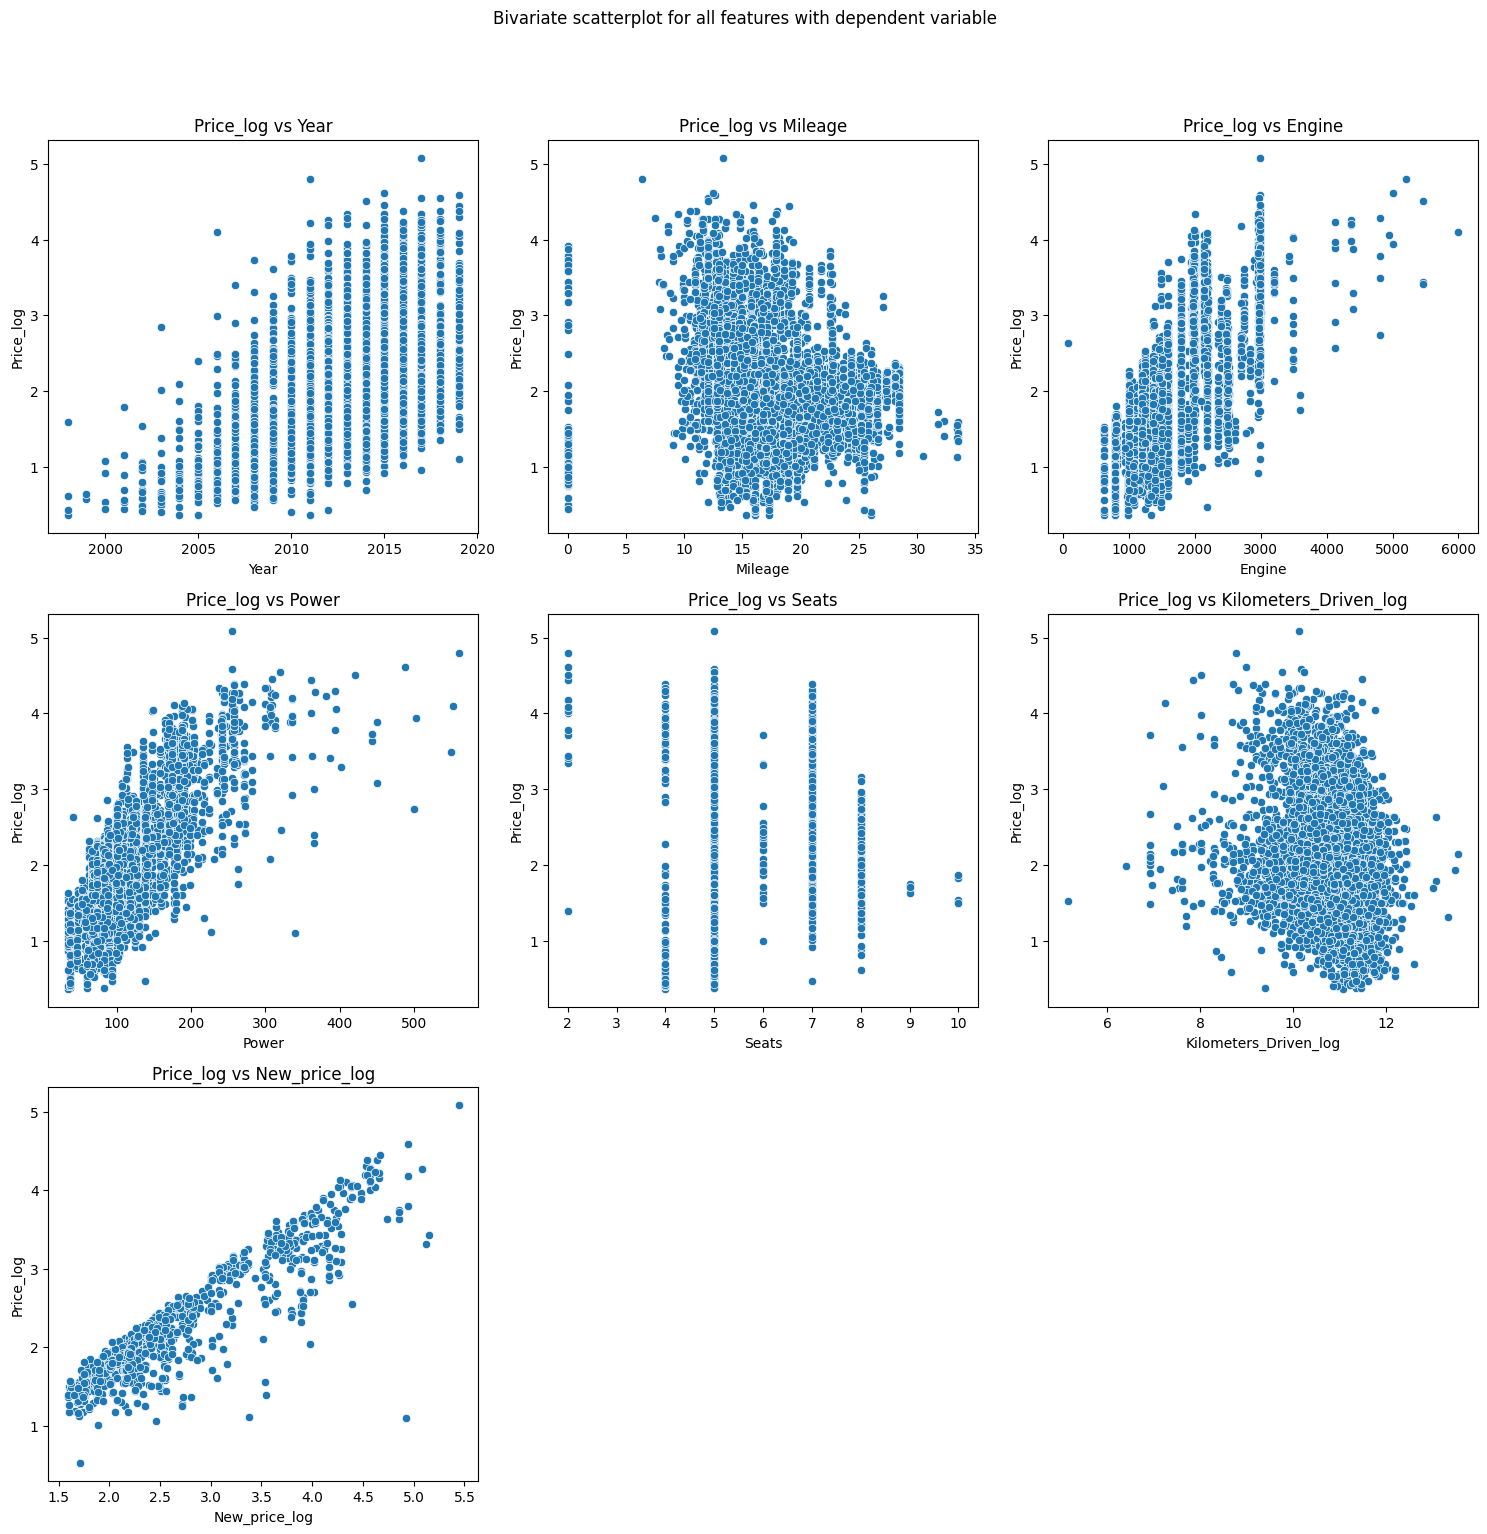

In [ ]:
#Bivariate analysis - relationship between Price and each independent numerical variable

#Define plot area and title
predictors = [col for col in data_clean.columns if col not in ['Price', 'Price_log', 'Name', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type',
                                                               'New_price', 'Kilometers_Driven']]
n_cols = 3
n_rows = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

#Loop through each col in dataset and plot
for ax, col in zip(axes, predictors):
    sb.scatterplot(data_clean, x=col, y='Price_log', ax=ax)
    ax.set_title(f"Price_log vs {col}")
fig.suptitle("Bivariate scatterplot for all features with dependent variable")

#Remove empty plot boxes
for ax in axes[len(predictors):]:
    fig.delaxes(ax)

#Adjust spacing between subplots for better visualisation
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

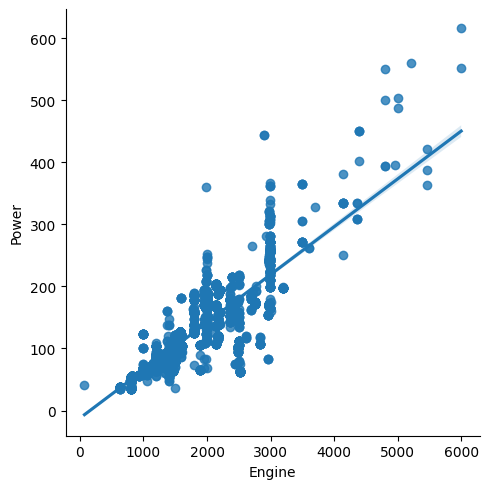

In [ ]:
#Bivariate analysis - observe the highly correlated independent variables

sb.lmplot(data_clean, x='Engine', y='Power')

Observations:

- There is no clear relationship between our dependent variable and Mileage, Seats and Kilometers_Driven.
- There are positive correlations between our dependent variable and Year, Engine, Power and New_price.
- The findings make sense, since new models of cars tend to be more expensive than older models. Similarly, cars with a larger and more powerful engine would be priced higher than those with smaller or less powerful engines.
- The correlation between used car price and new car price is interesting, as it shows us that as for the same brand/model car, used car price increases as the matched new car price increases. However, new car price will always be more expensive than the used car.
- When observing the correlation between the two independent variables, Power and Engine, we see a positive trend where engine power increases as engine volume does. This makes sense in the context of car manufacturing and design.

<Axes: xlabel='Price_log', ylabel='Location'>

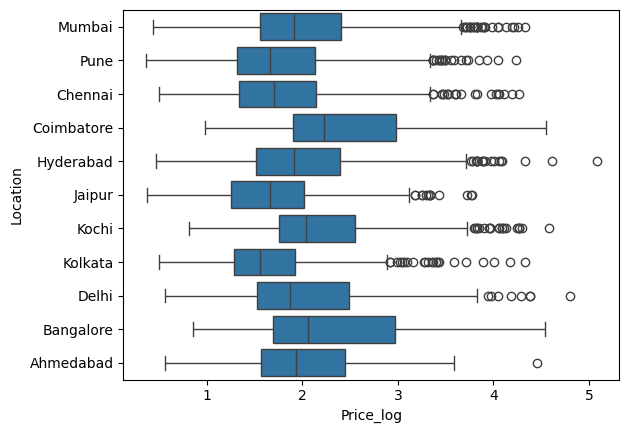

In [ ]:
#Box plot for dependent variable and 'Location'

sb.boxplot(data_clean, x='Price_log', y='Location')

Observations:

- When comparing the dependent variable with location, we can observe that most cities sell similar priced used cars, with Coimbatore's median value higher than other cities.
- All cities have outliers, with some used cars sold for higher price than the bulk they have in store.

### **Feature Engineering**

**Think about it:** The `Name` column in the current format might not be very useful in our analysis.
Since the name contains both the brand name and the model name of the vehicle, the column would have too many unique values to be useful in prediction. Can we extract that information from that column?

* **Hint:** With 2041 unique names, car names are not going to be great predictors of the price in our current data. But we can process this column to extract important information for example brand name.

In [ ]:
#Tidy up car name column - take first word as 'Brand'

data_clean['Brand'] = data_clean['Name'].str.split().str[0]
data_clean['Brand'].value_counts()

#Clean up 'ISUZU' and 'Isuzu'
data_clean['Brand'] = data_clean['Brand'].str.replace('ISUZU', 'Isuzu')

#Clean up 'Land' to 'Land Rover'
data_clean['Brand'] = data_clean['Brand'].str.replace('Land', 'Land Rover')

data_clean['Brand'].value_counts()


,count
Brand,
Maruti,1444
Hyundai,1340
Honda,743
Toyota,507
Mercedes-Benz,380
Volkswagen,374
Ford,351
Mahindra,331
BMW,311


In [ ]:
#Check unique values in new Brand column

data_clean['Brand'].describe()
data_clean['Brand'].unique()

array(['Maruti', 'Hyundai', 'Honda', 'Audi', 'Nissan', 'Toyota',
       'Volkswagen', 'Tata', 'Land Rover', 'Mitsubishi', 'Renault',
       'Mercedes-Benz', 'BMW', 'Mahindra', 'Ford', 'Porsche', 'Datsun',
       'Jaguar', 'Volvo', 'Chevrolet', 'Skoda', 'Mini', 'Fiat', 'Jeep',
       'Smart', 'Ambassador', 'Isuzu', 'Force', 'Bentley', 'Lamborghini',
       'Hindustan', 'OpelCorsa'], dtype=object)

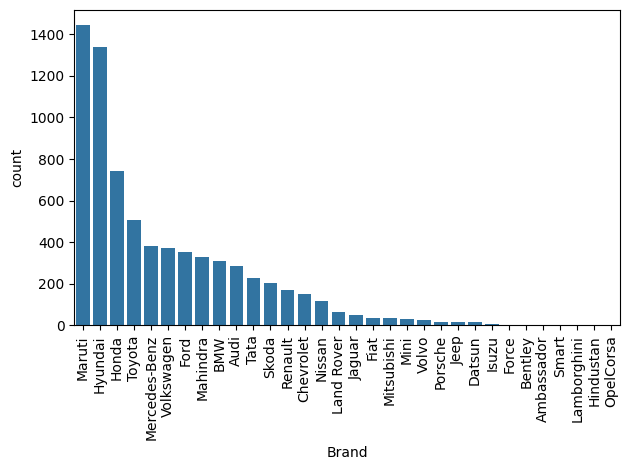

In [ ]:
#Plot Brand column to check distribution

sb.countplot(data_clean, x='Brand',
             order=data_clean['Brand'].value_counts().index)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Observations:

- We engineered the Name column to extract only the brand name.
- This reduced the number of observations from 2041 unique values to 32 unique brand names, which is better for the model's prediction.
- The distribution of the brand names shows that Maruti and Hyundai are the most popular cars in the dataset.

### **Missing value treatment**

In [ ]:
#Check which variables have missing values and the percentage of that variable that is missing

missing_summary = pd.DataFrame({'Missing Count': data_clean.isna().sum(),
                                'Missing Proportion (%)': data_clean.isna().mean() * 100})

missing_summary

,Missing Count,Missing Proportion (%)
Name,0,0.000000
Location,0,0.000000
Year,0,0.000000
Kilometers_Driven,0,0.000000
Fuel_Type,0,0.000000
Transmission,0,0.000000
Owner_Type,0,0.000000
Mileage,2,0.027579
Engine,46,0.634308
Power,175,2.413127


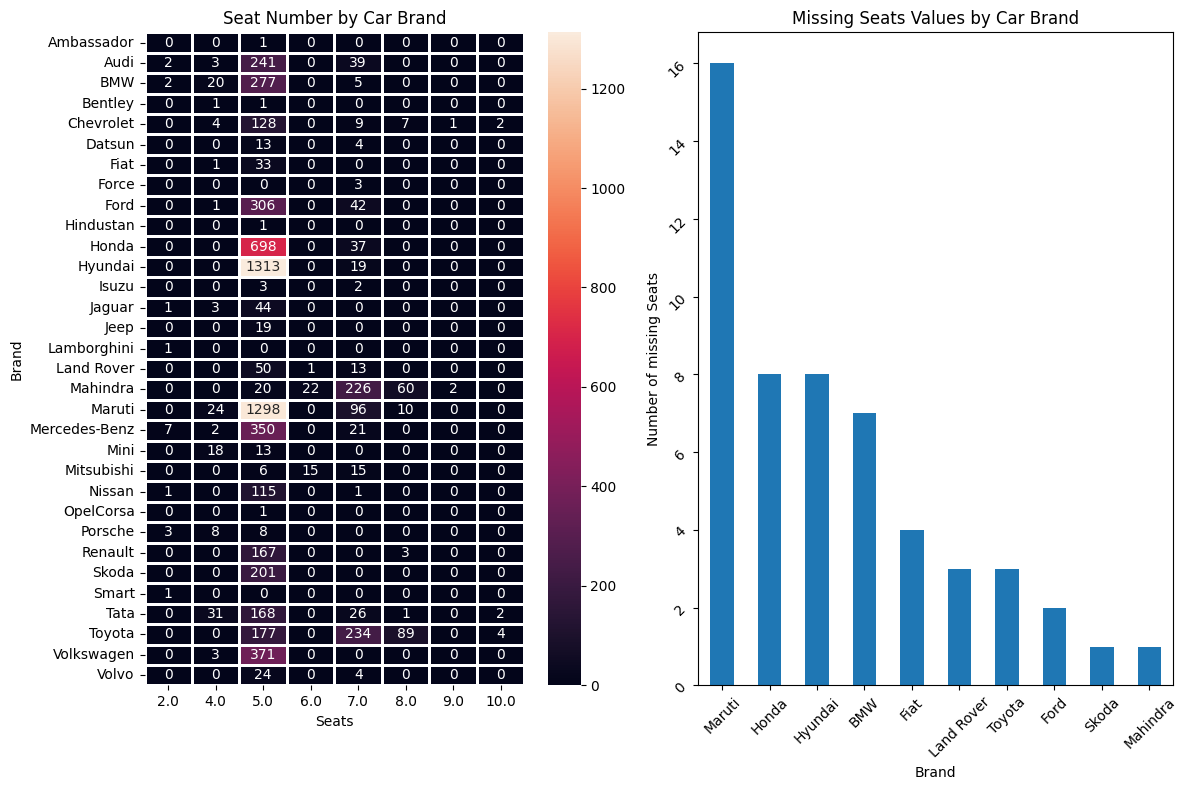

In [ ]:
#Missing value treatment - Seats

#First, let's try to understand if there are any associations between seat numbers and car brands
fig, axes = plt.subplots(1, 2, figsize=(12, 8))

#Plot seat numbers and car brand names
seat_counts = pd.crosstab(data_clean['Brand'], data_clean['Seats'])
sb.heatmap(seat_counts, annot=True, fmt='d', linewidths=1, linecolor='white', ax=axes[0])
axes[0].set_title("Seat Number by Car Brand")

#Plot missing seat values and car brand names
missing_seats = (data_clean[data_clean['Seats'].isna()]['Brand'].value_counts())
missing_seats.plot(kind='bar', ax=axes[1])
axes[1].set_ylabel('Number of missing Seats')
axes[1].set_title('Missing Seats Values by Car Brand')
axes[1].tick_params(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
#Missing value treatment - Seats

#Most car brands have 5-seater cars as the most common value, except for Toyota and Mahindra who have 7-seater cars

#Imput missing seat values for all cars using MODE value from car brand names
data_clean['Seats'] = data_clean.groupby('Brand')['Seats'].transform(lambda x: x.fillna(x.mode()[0]))

#Check missing values again
data_clean['Seats'].isna().sum()


np.int64(0)

In [ ]:
#Missing value treatment - Price, Engine, Mileage

#Impute missing values for these columns using MEDIAN value (due to skewness)
cols = ['Power', 'Engine', 'Mileage']

for col in cols:
    data_clean[col] = data_clean[col].fillna(data_clean[col].median())

#Check missing values again
#data_clean.isna().sum()

In [ ]:
#Missing value treatment - New Price and Used Price

#For new car price, given a large number of values are missing, we will drop this col
data_clean = data_clean.drop(columns=['New_price', 'New_price_log'])

#For used car price, given this is the dependent variable, we will drop rows that have missing values
data_clean = data_clean.dropna(subset=['Price', 'Price_log']).copy()

#Check missing values again
#data_clean.isna().sum()

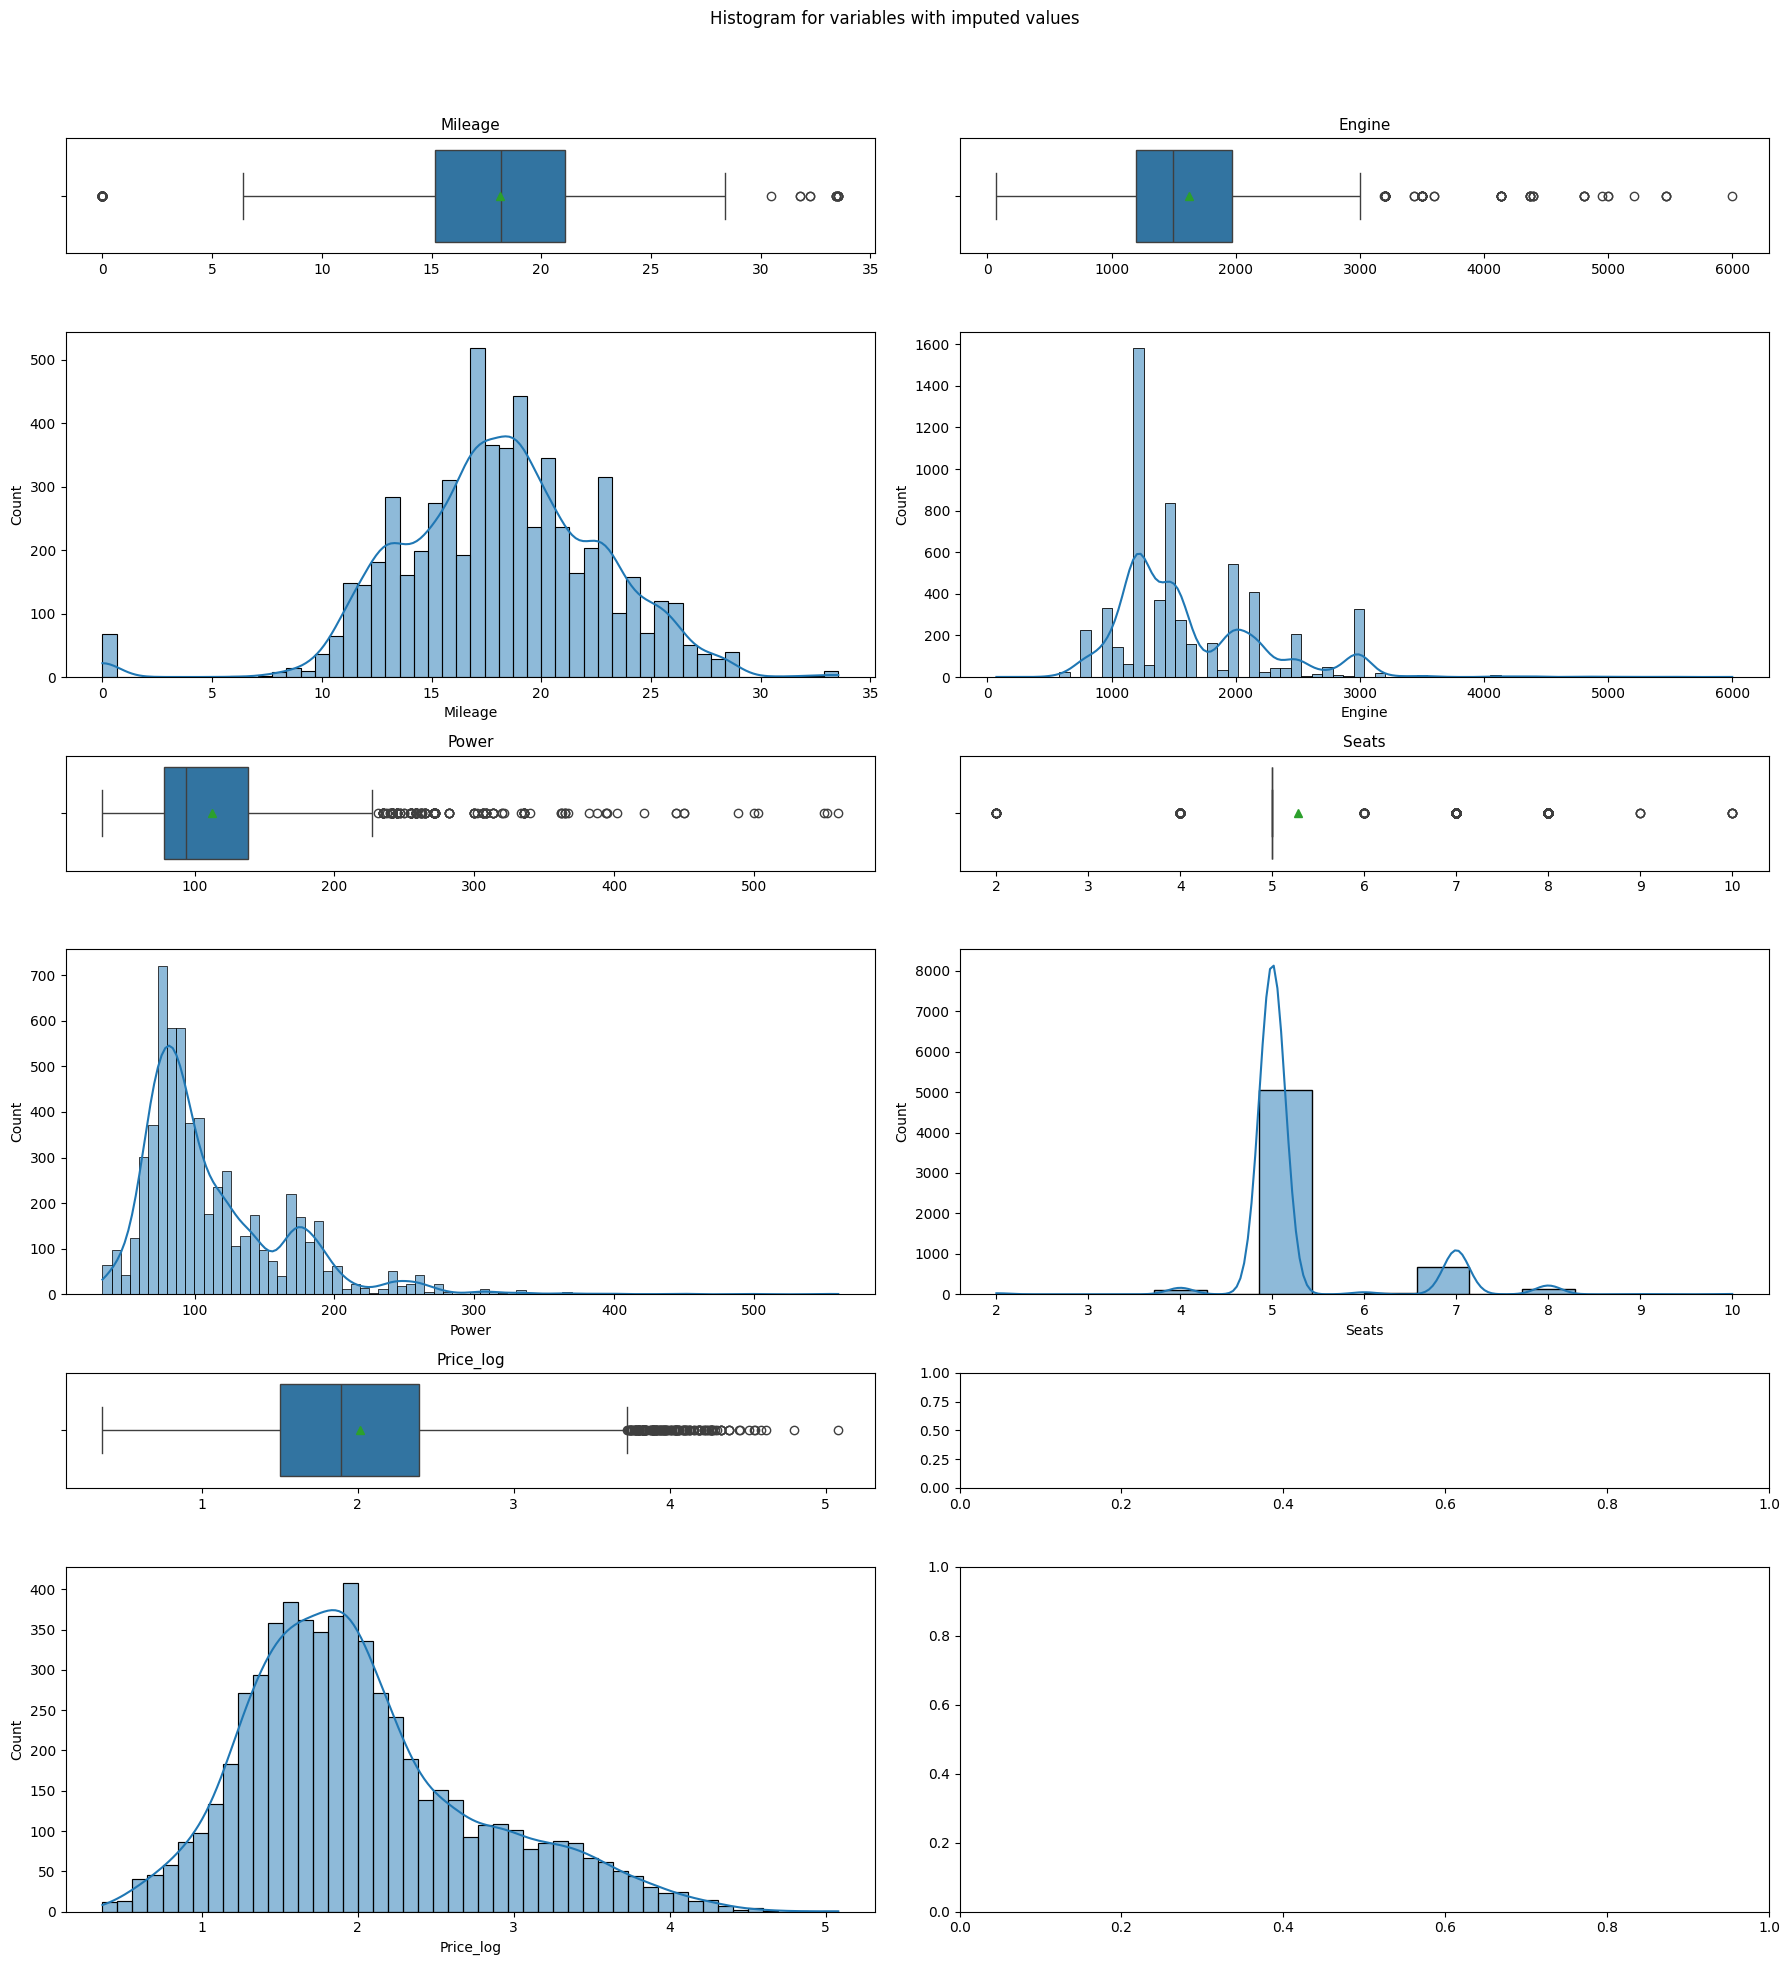

In [ ]:
#Check distribution of variables to ensure imputed values did not change it significantly

#Define plot area and title
cols = ['Mileage', 'Engine', 'Power', 'Seats', 'Price_log']
n_cols = 2
n_rows = 3
n_groups = 3
fig, axes = plt.subplots(nrows=n_groups * 2,
                         ncols=n_cols,
                         figsize=(18, 20),
                         gridspec_kw={"height_ratios": [1, 3] * n_groups})

#Loop through each col in dataset and plot
for i, col in enumerate(cols):
    row = (i // n_cols) * 2   # Boxplot row
    c = i % n_cols            # Column

    # Boxplot
    sb.boxplot(x=data_clean[col], ax=axes[row, c], showmeans=True)
    axes[row, c].set_title(col, fontsize=11)
    axes[row, c].set_xlabel("")

    # Histogram
    sb.histplot(data=data_clean, x=col, kde=True, ax=axes[row + 1, c])
    axes[row + 1, c].set_xlabel(col)

fig.suptitle("Histogram for variables with imputed values")

#Adjust spacing between subplots for better visualisation
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Observations:

- There were missing values in Mileage, Engine, Power, Seats, New_price and Price.
- We imputed missing values for Mileage, Engine, Power, and Seats, using either mode or median values.
- 86% of New_price values are missing, so this cannot be reliably imputed. We can drop this column before performing linear regression, as this won't help improve our model's prediction.
- 17% of Price values are missing. Since this is our dependent variable, it is not good practice to impute missing values, so these rows were dropped.
- After imputing missing values, we checked the distribution of those variables and confirmed it did not significantly change.
- After data tidying and processing, we are left with 6018 rows and 15 columns, with no missing or duplicate values.

## **Important Insights from EDA and Data Preprocessing**

What are the the most important observations and insights from the data based on the EDA and Data Preprocessing performed?

Observations:

- The dataset had 7253 rows and 14 columns. This was a mixture of numerical and categorial variables.
- We used feature engineering to reformat Name into a more digestible variable, Brand. This reduced the number of values from 2041 to 32 unique car brand names.
- There were missing values, outliers and high skewness observed across multiple variables.
- Missing values were dealt with through either imputation or removal.  
- We decided to completely drop New_price, given the large number of missing values present (86%).
- Outliers were removed and the high skewness of variables was accounted for through log transformation.
- Serial number was dropped because it didn't add additional value to the dataset.
- After data tidying, the dataset has 6018 rows and 15 columns.

Insights:

- Our analysis shows us that most used cars have 5 seats, have a manual transmission and have one previous owner.
- The Maruti car brand has the highest number of used cars in the dataset.
- Bivariate analysis shows us that Price is highly correlated with Power and Engine.
- Price is also highly correlated with New_price; however, with the majority of values missing for this variable, this correlation could be misleading.
- This is a linear relationship between Price and Year, Engine and Power. This suggests that newer manufactured cars, with larger engine volumes and power often lead to a higher price for used cars.
- There was no strong relationship between Price and Mileage, Seats or Kilometers_Driven. This suggests that these factors might not greatly influence used car price.

## **Building Various Models**


1. What we want to predict is the "Price". We will use the normalized version 'price_log' for modeling.
2. Before we proceed to the model, we'll have to encode categorical features. We will drop categorical features like Name.
3. We'll split the data into train and test, to be able to evaluate the model that we build on the train data.
4. Build Regression models using train data.
5. Evaluate the model performance.

### **Split the Data**

<li>Step1: Seperating the indepdent variables (X) and the dependent variable (y).
<li>Step2: Encode the categorical variables in X using pd.dummies.
<li>Step3: Split the data into train and test using train_test_split.

**Question:**

1. Why we should drop 'Name','Price','price_log','Kilometers_Driven' from X before splitting?

**Answer:**

We drop the variables Name, Price, Price_log, Kilometers_Driven because:
1. Name contains too many unique values and will not help our model better predict used car prices. The new column Brand, which extracted relevant information from Name, will be more useful as a feature in our prediction modeling.
2. Before splitting, we need to form our dependent variable and independent variable arrays. Price_log is our dependent variable, so the untransformed Price variable is no longer needed, and both variables will be excluded when forming the indepedent variable array.
3. Kilometers_Driven was log transformed into Kilometers_Driven_log. We will use the latter for our models, so we can drop the former variable.

In [ ]:
#Preparing data for modeling
from sklearn.model_selection import train_test_split

#Split data up into 'y' dependent and 'X' independent variables
dependent_var = data_clean['Price_log']
independent_vars = data_clean.drop(columns=['Price', 'Price_log', 'Name', 'Kilometers_Driven'])

In [ ]:
#Encode the categorical variables (Location, Fuel_Type, Transmission, Owner_Type, Brand) and drop the first reference value
independent_vars = pd.get_dummies(independent_vars, drop_first = True)
independent_vars.head()

,Year,Mileage,Engine,Power,Seats,Kilometers_Driven_log,Location_Bangalore,Location_Chennai,Location_Coimbatore,Location_Delhi,...,Brand_Mitsubishi,Brand_Nissan,Brand_Porsche,Brand_Renault,Brand_Skoda,Brand_Smart,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Brand_Volvo
0,2010,26.60,998.0,58.16,5.0,11.184421,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2015,19.67,1582.0,126.20,5.0,10.621327,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2011,18.20,1199.0,88.70,5.0,10.736397,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2012,20.77,1248.0,88.76,7.0,11.373663,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2013,15.20,1968.0,140.80,5.0,10.613246,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
#Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(independent_vars, dependent_var, test_size = 0.30, random_state = 1)

#Check size of train and test sets
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4212, 53)
(1806, 53)
(4212,)
(1806,)


Observations:

- We created our independent variables (X) and dependent variable (y) arrays, dropping the variables no longer needed.
- We used one-hot encoding to convert our categorical variables into numerical variables, to make them better suited for regression modeling. We dropped the first category in each of those variables, since they become our reference category during modeling.
- We split the data 70:30 into train and test datasets.

For Regression Problems, some of the algorithms used are :<br>

**1) Linear Regression** <br>
**2) Ridge / Lasso Regression** <br>
**3) Decision Trees** <br>
**4) Random Forest** <br>

### **Linear Regression**

In [ ]:
##Linear regression OLS modeling

#Scale numerical variables - using MinMaxScaler because we also have categorical vars present
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, index = X_train.index, columns = X_train.columns)
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, index = X_test.index, columns = X_test.columns)

#Add the intercept term
X_train_ols = sm.add_constant(X_train_scaled)
X_test_ols = sm.add_constant(X_test_scaled)

#Check for multicollinearity
#Calculate VIF score
vif_series = pd.Series(
    [variance_inflation_factor(X_train_ols.values, i) for i in range(X_train_ols.shape[1])],
    index = X_train_ols.columns,
    dtype = float)

print("VIF Scores: \n\n{}\n".format(vif_series))

#Call and fit the OLS model
ols_model_1 = sm.OLS(y_train, X_train_ols).fit()

print(ols_model_1.summary())

VIF Scores: 

const                        4673.439783
Year                            2.210948
Mileage                         3.138450
Engine                         10.100717
Power                           9.032845
Seats                           2.407473
Kilometers_Driven_log           1.783724
Location_Bangalore              2.365733
Location_Chennai                2.816251
Location_Coimbatore             3.446011
Location_Delhi                  3.022387
Location_Hyderabad              3.700663
Location_Jaipur                 2.576464
Location_Kochi                  3.429232
Location_Kolkata                3.029353
Location_Mumbai                 3.904368
Location_Pune                   3.263546
Fuel_Type_Diesel               29.217634
Fuel_Type_Electric              1.035791
Fuel_Type_LPG                   1.203983
Fuel_Type_Petrol               30.215203
Transmission_Manual             2.234240
Owner_Type_Fourth & Above       1.013269
Owner_Type_Second               1.182996
Ow

Observations:

- We needed to scale the data and add an intercept term because we are using statsmodel pacakge and this is required for it.
- The R2 value for Model 1 is very high (0.924), which suggests the model can predict used car price very well given the current features.
- The coefficient value for Power and Year are the highest amongst the independent variables, suggesting these features influence Price_log the most.
- The p-value is statistically significant for most variables, with some of the Brand features having the least significance (p>0.05)
- When accessing multicollinearity, we observe several variables with very high VIF scores, mostly within the Brand variable. This suggests the model is impacted by these features as they have high correlation with other features.
- We will remove the Brand features with the highest VIF score and assess the model performance again.
- After each iteration, we will observe VIF scores, R2 value and p-values to assess model performance and remove features that are insignificant.







In [ ]:
#Remove features for OLS model 2
X_train_ols_2 = X_train_ols.drop(columns=['Brand_Maruti'])

#Calculate VIF score
vif_series = pd.Series(
    [variance_inflation_factor(X_train_ols_2.values, i) for i in range(X_train_ols_2.shape[1])],
    index = X_train_ols_2.columns,
    dtype = float)

print("VIF Scores: \n\n{}\n".format(vif_series))

#Call and fit the OLS model
ols_model_2 = sm.OLS(y_train, X_train_ols_2).fit()

print(ols_model_2.summary())

VIF Scores: 

const                        496.808354
Year                           2.210111
Mileage                        3.134490
Engine                        10.094363
Power                          9.017349
Seats                          2.405954
Kilometers_Driven_log          1.782594
Location_Bangalore             2.365722
Location_Chennai               2.814702
Location_Coimbatore            3.445897
Location_Delhi                 3.022367
Location_Hyderabad             3.700641
Location_Jaipur                2.576352
Location_Kochi                 3.429123
Location_Kolkata               3.029351
Location_Mumbai                3.904367
Location_Pune                  3.263470
Fuel_Type_Diesel              29.215739
Fuel_Type_Electric             1.035791
Fuel_Type_LPG                  1.203978
Fuel_Type_Petrol              30.214620
Transmission_Manual            2.234213
Owner_Type_Fourth & Above      1.013251
Owner_Type_Second              1.182965
Owner_Type_Third          

In [ ]:
#Remove features for OLS model 3
X_train_ols_3 = X_train_ols_2.drop(columns=['Fuel_Type_Petrol'])

#Calculate VIF score
vif_series = pd.Series(
    [variance_inflation_factor(X_train_ols_3.values, i) for i in range(X_train_ols_3.shape[1])],
    index = X_train_ols_3.columns,
    dtype = float)

print("VIF Scores: \n\n{}\n".format(vif_series))

#Call and fit the OLS model
ols_model_3 = sm.OLS(y_train, X_train_ols_3).fit()

print(ols_model_3.summary())

VIF Scores: 

const                        320.450365
Year                           2.210097
Mileage                        2.963975
Engine                         9.969975
Power                          8.983957
Seats                          2.404140
Kilometers_Driven_log          1.774450
Location_Bangalore             2.365557
Location_Chennai               2.814114
Location_Coimbatore            3.443955
Location_Delhi                 3.022254
Location_Hyderabad             3.699225
Location_Jaipur                2.573898
Location_Kochi                 3.428793
Location_Kolkata               3.027669
Location_Mumbai                3.903496
Location_Pune                  3.262813
Fuel_Type_Diesel               2.347680
Fuel_Type_Electric             1.010496
Fuel_Type_LPG                  1.011487
Transmission_Manual            2.234196
Owner_Type_Fourth & Above      1.013250
Owner_Type_Second              1.182952
Owner_Type_Third               1.140368
Brand_Audi                

In [ ]:
#Remove features for OLS model 4
X_train_ols_4 = X_train_ols_3.drop(columns=['Engine'])

#Calculate VIF score
vif_series = pd.Series(
    [variance_inflation_factor(X_train_ols_4.values, i) for i in range(X_train_ols_4.shape[1])],
    index = X_train_ols_4.columns,
    dtype = float)

print("VIF Scores: \n\n{}\n".format(vif_series))

#Call and fit the OLS model
ols_model_4 = sm.OLS(y_train, X_train_ols_4).fit()

print(ols_model_4.summary())

VIF Scores: 

const                        317.695374
Year                           2.201916
Mileage                        2.723502
Power                          3.690406
Seats                          2.250422
Kilometers_Driven_log          1.774303
Location_Bangalore             2.365530
Location_Chennai               2.814106
Location_Coimbatore            3.443553
Location_Delhi                 3.022250
Location_Hyderabad             3.697726
Location_Jaipur                2.573637
Location_Kochi                 3.428488
Location_Kolkata               3.027409
Location_Mumbai                3.902890
Location_Pune                  3.262644
Fuel_Type_Diesel               2.060725
Fuel_Type_Electric             1.009784
Fuel_Type_LPG                  1.011449
Transmission_Manual            2.233931
Owner_Type_Fourth & Above      1.013142
Owner_Type_Second              1.182732
Owner_Type_Third               1.140338
Brand_Audi                     1.933236
Brand_BMW                 

In [ ]:
#Remove features for OLS model 5
X_train_ols_5 = X_train_ols_4.drop(columns=['Location_Chennai', 'Location_Jaipur', 'Location_Kochi', 'Location_Pune',
                                            'Fuel_Type_LPG', 'Owner_Type_Fourth & Above', 'Brand_Ford', 'Brand_Force',
                                            'Brand_Isuzu', 'Brand_Nissan', 'Brand_Smart', 'Brand_Volkswagen'])

#Calculate VIF score
vif_series = pd.Series(
    [variance_inflation_factor(X_train_ols_5.values, i) for i in range(X_train_ols_5.shape[1])],
    index = X_train_ols_5.columns,
    dtype = float)

print("VIF Scores: \n\n{}\n".format(vif_series))

#Call and fit the OLS model
ols_model_5 = sm.OLS(y_train, X_train_ols_5).fit()

print(ols_model_5.summary())

VIF Scores: 

const                    283.225781
Year                       2.079376
Mileage                    2.436771
Power                      3.667525
Seats                      2.133123
Kilometers_Driven_log      1.761333
Location_Bangalore         1.113636
Location_Coimbatore        1.207413
Location_Delhi             1.145673
Location_Hyderabad         1.202926
Location_Kolkata           1.198899
Location_Mumbai            1.247508
Fuel_Type_Diesel           1.880184
Fuel_Type_Electric         1.009634
Transmission_Manual        2.225423
Owner_Type_Second          1.167668
Owner_Type_Third           1.129114
Brand_Audi                 1.695916
Brand_BMW                  1.954365
Brand_Bentley              1.064763
Brand_Chevrolet            1.057204
Brand_Datsun               1.016970
Brand_Fiat                 1.018342
Brand_Honda                1.296832
Brand_Hyundai              1.352534
Brand_Jaguar               1.236763
Brand_Jeep                 1.043357
Brand_Lamborgh

Observations:

- After 5 iterations, we finally have a good model, with no multicollinearity observed and features which have a significant effect on Price_log prediction.
- We will now compare each model's performance and use cross-validation to observe if the model has overfitted or underfitted the training dataset.

In [ ]:
#Check model metrics

models = {'Model 1': ols_model_1,
          'Model 2': ols_model_2,
          'Model 3': ols_model_3,
          'Model 4': ols_model_4,
          'Model 5': ols_model_5}
metrics = []

for name, model in models.items():
    metrics.append({
        'Model': name,
        'R²': model.rsquared,
        'MSE': model.mse_resid,
        'RMSE': np.sqrt(model.mse_resid)
    })

model_metrics = pd.DataFrame(metrics)

print(model_metrics.round(4))


     Model      R²     MSE    RMSE
0  Model 1  0.9240  0.0427  0.2066
1  Model 2  0.9240  0.0427  0.2066
2  Model 3  0.9240  0.0427  0.2066
3  Model 4  0.9226  0.0435  0.2085
4  Model 5  0.9223  0.0435  0.2086


In [ ]:
#Cross validation
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

linearregression = LinearRegression()

models = {'Model 1': X_train_ols,
          'Model 2': X_train_ols_2,
          'Model 3': X_train_ols_3,
          'Model 4': X_train_ols_4,
          'Model 5': X_train_ols_5}
metrics = []

cv_results = []

for name, X in models.items():
    cv_r2 = cross_val_score(linearregression, X, y_train, cv=10, scoring='r2')
    cv_mse = cross_val_score(linearregression, X, y_train, cv=10, scoring='neg_mean_squared_error')

    cv_results.append({
        "Model": name,
        "R²": cv_r2.mean(),
        "R² Std": cv_r2.std()*2,
        "MSE": -1*cv_mse.mean(),
        "MSE Std": cv_mse.std()*2
    })

cv_results = pd.DataFrame(cv_results)

print(cv_results.round(4))


     Model      R²  R² Std     MSE  MSE Std
0  Model 1  0.9205  0.0229  0.0442   0.0181
1  Model 2  0.9204  0.0227  0.0442   0.0181
2  Model 3  0.9204  0.0228  0.0443   0.0181
3  Model 4  0.9190  0.0246  0.0450   0.0194
4  Model 5  0.9191  0.0248  0.0450   0.0196


Observations:

- To observe if our model has been overfitted or underfitted, we performed cross-validation using 10-folds.
- This showed us that the cross-validated R2 and MSE values are very similar to the values from OLS model, suggesting all our models fit the data nicely.
- When comparing each iteration of our model, we can see Models 1-3 perform best. The removal of Engine and other features did not significantly improve performance.
- We will move forward with Model 3 for our final predictions, as this has a high R2 value (0.924), low MSE value (0.0427) and accounts for multicollinearity.
- We will also check the assumptions of linear regression, to evaluate Model 3's performance.

In [ ]:
#Check residuals
residuals = ols_model_3.resid
np.mean(residuals)

np.float64(-9.022855270785531e-15)

<Axes: ylabel='Count'>

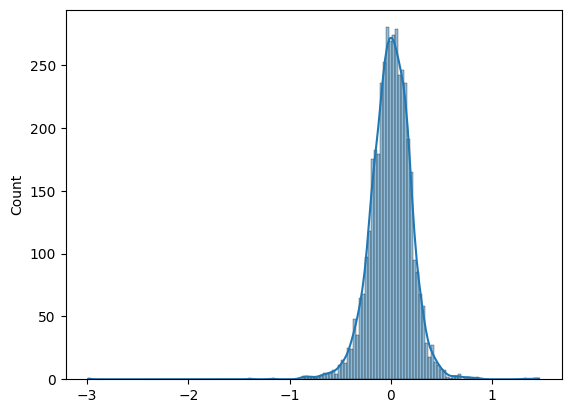

In [ ]:
#Check the normality of error terms
sb.histplot(residuals, kde = True)

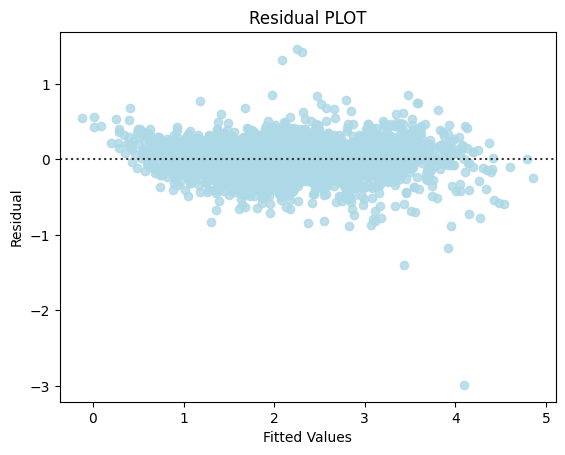

In [ ]:
#Check linear relationship of variables
fitted = ols_model_3.fittedvalues

sb.residplot(x = fitted, y = residuals, color = "lightblue")
plt.xlabel("Fitted Values")
plt.ylabel("Residual")
plt.title("Residual PLOT")
plt.show()

In [ ]:
#Check heteroscedasticity using Goldfeld–Quandt test
#pval >0.05 = no heteroscedasticity; pval <0.05 = heteroscedasticity present

from statsmodels.stats.diagnostic import het_white
from statsmodels.compat import lzip
import statsmodels.stats.api as sms

name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(y_train, X_train_ols_3)
lzip(name, test)


[('F statistic', np.float64(1.172544584689863)),
 ('p-value', np.float64(0.0001552488539590503))]

Observations:

- OLS Model 3 statisfies most linear regression assumptions, with mean of residuals close to 0, error terms normally distributed and no correlation seens between the residuals and fitted values.
- However, the model has heteroscedasticity present, with a significant p-value observed when performing the Goldfeld-Quandt test.
- This suggests there is variance present in the error terms and could lead to incorrect predictions.
- For now, let's move forward with OLS Model 3 and evaluate the model's prediction performance.

In [ ]:
#Define function to check model metrics
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

def model_metrics(model_name, y_train, train_predictions, y_test, test_predictions):

    metrics = pd.DataFrame({
        'Dataset': ['Train', 'Test'],
        'R²': [
            r2_score(y_train, train_predictions),
            r2_score(y_test, test_predictions)
        ],
        'MAE': [
            mean_absolute_error(y_train, train_predictions),
            mean_absolute_error(y_test, test_predictions)
        ],
        'MSE': [
            mean_squared_error(y_train, train_predictions),
            mean_squared_error(y_test, test_predictions)
        ],
        'RMSE': [
            np.sqrt(mean_squared_error(y_train, train_predictions)),
            np.sqrt(mean_squared_error(y_test, test_predictions))
        ]
    })

    print(f"\n{model_name}")
    print(metrics.round(4))

    return metrics

In [ ]:
#Drop variables from test dataset to match Model 3 features
X_test_ols_3 = X_test_ols.drop(columns=['Brand_Maruti', 'Fuel_Type_Petrol'])

#Predict using OLS Model 3
ols_train_predictions = ols_model_3.predict(X_train_ols_3)
ols_test_predictions = ols_model_3.predict(X_test_ols_3)

#Check model metrics
ols_metrics = model_metrics('OLS Model 3',
                            y_train,
                            ols_train_predictions,
                            y_test,
                            ols_test_predictions)



OLS Model 3
  Dataset      R²     MAE     MSE    RMSE
0   Train  0.9240  0.1511  0.0422  0.2054
1    Test  0.9308  0.1501  0.0393  0.1984


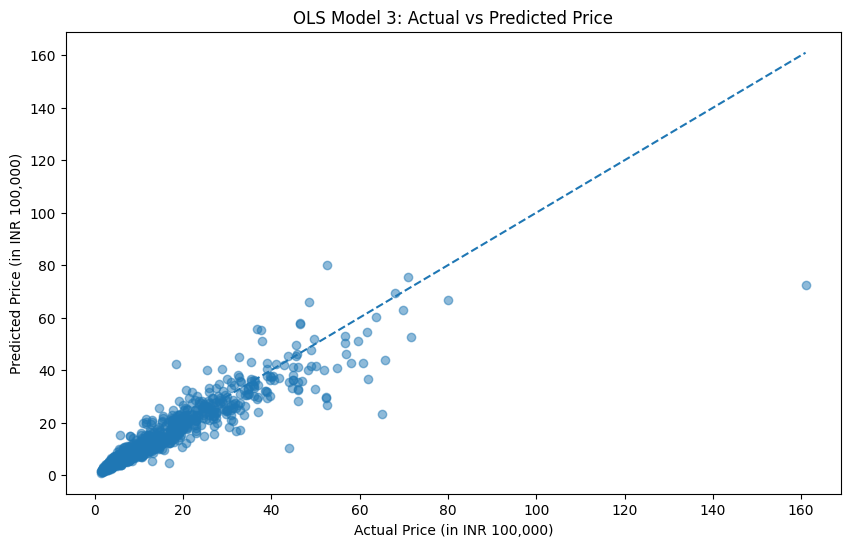

In [ ]:
#Plot actual vs predicted price

#We used Price_log, so must account for log transformation
test_predictions_exp = np.exp(ols_test_predictions)
test_observed_exp = np.exp(y_test)

plt.figure(figsize=(10, 6))

plt.scatter(test_observed_exp, test_predictions_exp, alpha=0.5)
plt.plot([test_observed_exp.min(), test_observed_exp.max()], [test_observed_exp.min(), test_observed_exp.max()], '--')

plt.xlabel('Actual Price (in INR 100,000)')
plt.ylabel('Predicted Price (in INR 100,000)')
plt.title('OLS Model 3: Actual vs Predicted Price')
plt.show()

Observations:

- OLS Model 3 does a very good job at predicting used car prices, with a high R2 value observed (0.924 for train and 0.931 for test) and low RMSE/MSE/MAE values.
- The model predicts used car prices well up to INR 4,000,000, with some variation observe after this price point. This could be due to the fact that most used cars in this dataset were priced below INR 4,000,000.
- There seems to be an outlier when observing this scatterplot, but earlier in our EDA section we noted this was not an outlier but a true data point. We won't remove this for now and carry on with our analysis.
- Although heteroscedasticity is present in this model, it works well to predict used car prices.
- We will now use a regularisation regression model to see if model performance improves.

### **Regularisation: Ridge Regression**

In [ ]:
#Ridge regression
from sklearn.linear_model import Ridge

#Call and fit the model
ridge = Ridge()
ridge.fit(X_train_scaled, y_train)

#Predict using Ridge regression model
ridge_train_predictions = ridge.predict(X_train_scaled)
ridge_test_predictions = ridge.predict(X_test_scaled)

#Check model metrics
ridge_metrics = model_metrics('Ridge',
                            y_train,
                            ridge_train_predictions,
                            y_test,
                            ridge_test_predictions)



Ridge
  Dataset      R²     MAE     MSE    RMSE
0   Train  0.9237  0.1518  0.0423  0.2057
1    Test  0.9298  0.1514  0.0399  0.1998


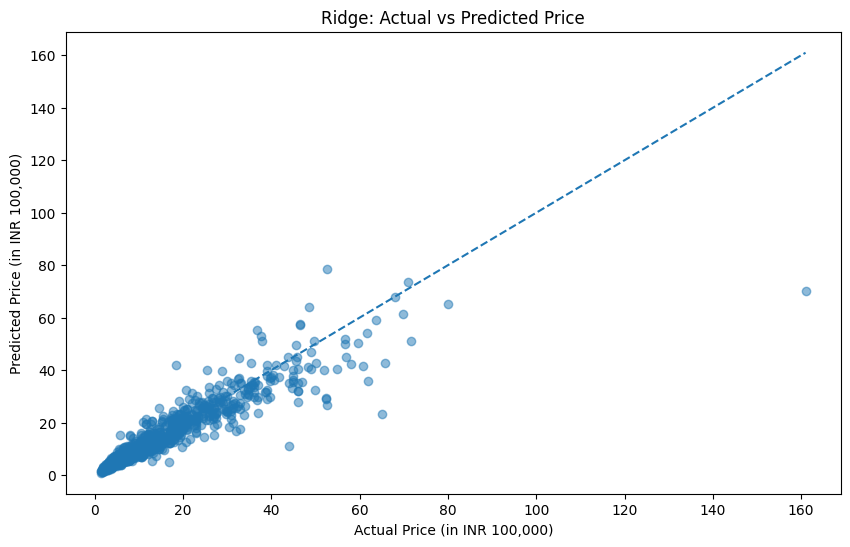

In [ ]:
#Plot actual vs predicted price

#We used Price_log, so must account for log transformation
test_predictions_exp = np.exp(ridge_test_predictions)
test_observed_exp = np.exp(y_test)

plt.figure(figsize=(10, 6))

plt.scatter(test_observed_exp, test_predictions_exp, alpha=0.5)
plt.plot([test_observed_exp.min(), test_observed_exp.max()], [test_observed_exp.min(), test_observed_exp.max()], '--')

plt.xlabel('Actual Price (in INR 100,000)')
plt.ylabel('Predicted Price (in INR 100,000)')
plt.title('Ridge: Actual vs Predicted Price')
plt.show()

Observations:

- We performed regularisation to evaluate if a different regression may improve the prediction performance. Typically, this regression model is used to account for overfitting or underfitting, but can help to reduce any variance observed in the dataset.
- We selected ridge regression to reduce the weights (coefficients) of the features without eliminating them.
- The ridge regression model performs very well on the test dataset, with a high R2 value observed (0.929) and low RMSE/MSE/MAE values.
- Next, we will evaluate if non-linear regression models can help improve model performance.

### **Hyperparameter Tuning: Decision Tree**

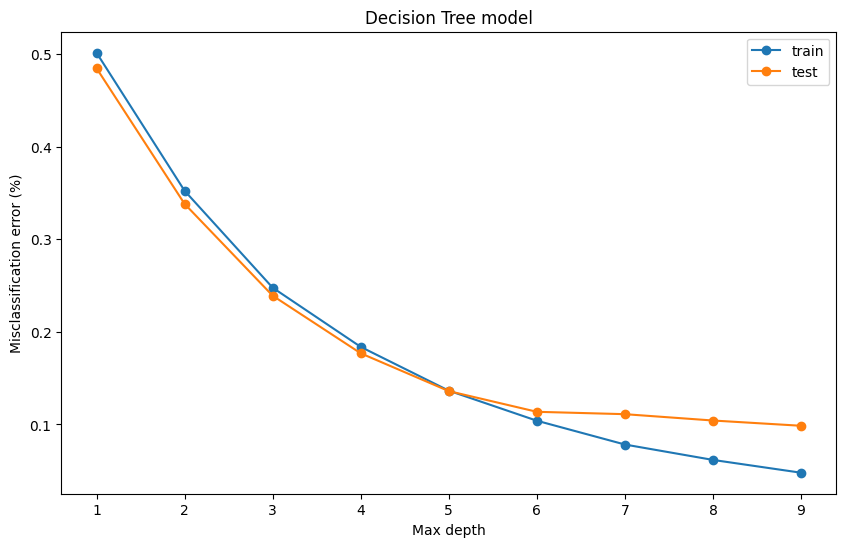

In [ ]:
#Non-linear regression modeling - decision trees
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree

#Firstly, we loop to find the optimal depth of the decision tree
train_scores = []
test_scores = []

for depth in range(1, 10):
    reg = DecisionTreeRegressor(
        max_depth=depth,
        random_state=14)

    #Fit the model
    reg.fit(X_train, y_train)

    #Obtain misclassification error
    train_scores.append(1- reg.score(X_train, y_train))
    test_scores.append(1- reg.score(X_test, y_test))

#Plot graph
plt.plot(range(1, 10), train_scores, '-o', label='train')
plt.plot(range(1, 10), test_scores, '-o', label='test')

plt.legend(loc='best')
plt.xlabel('Max depth')
plt.ylabel('Misclassification error (%)')
plt.title('Decision Tree model')
fig = plt.gcf()
fig.set_size_inches(10, 6)
plt.show()

In [ ]:
#Call and fit Decision Tree model - use max_depth=5 for final model
dt_regressor = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_regressor.fit(X_train, y_train)

#Predict using Decision Tree regression model
dt_train_predictions = dt_regressor.predict(X_train)
dt_test_predictions = dt_regressor.predict(X_test)

#Check model metrics
dt_metrics = model_metrics('Decision Tree',
                            y_train,
                            dt_train_predictions,
                            y_test,
                            dt_test_predictions)


Decision Tree
  Dataset      R²     MAE     MSE    RMSE
0   Train  0.8636  0.2028  0.0757  0.2751
1    Test  0.8640  0.2107  0.0773  0.2780


**Feature Importance**

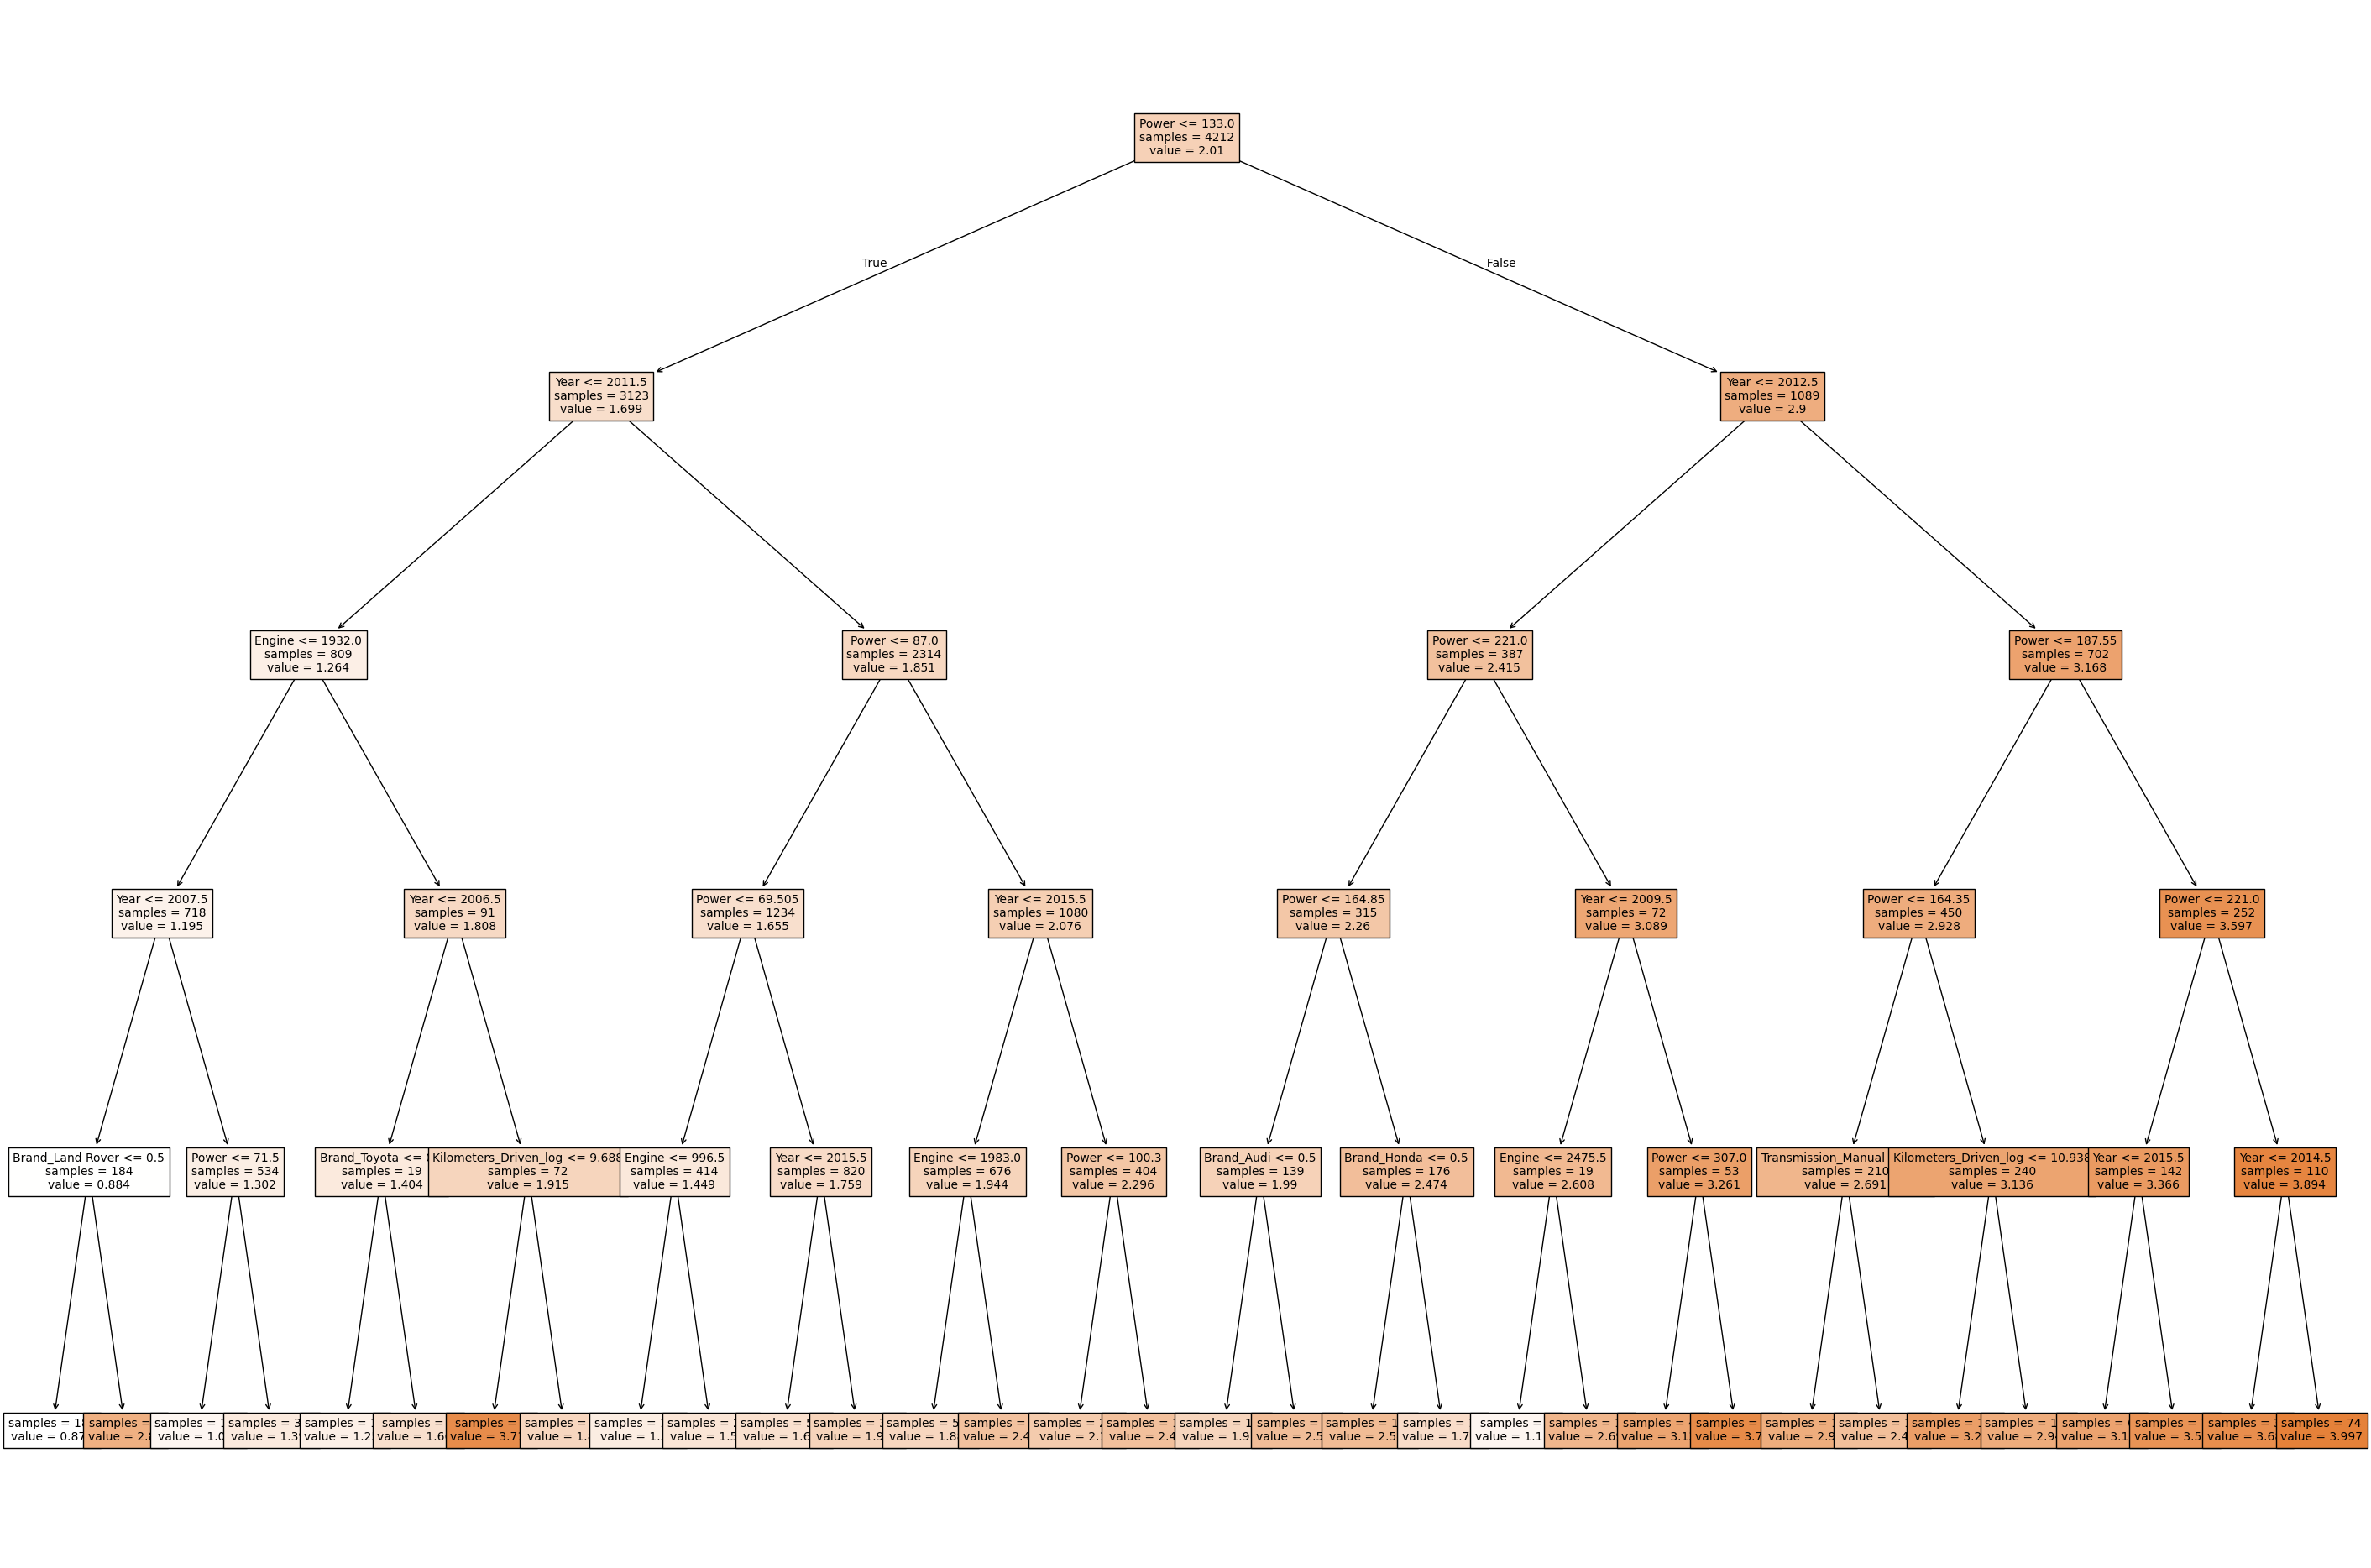

In [ ]:
#Plot decision tree
from sklearn import tree

fig, ax = plt.subplots(figsize=(36, 24))

out = tree.plot_tree(dt_regressor,
                     max_depth=5,
                     fontsize=10,
                     impurity=False,
                     filled=True,
                     feature_names=X_train.columns)

plt.show()

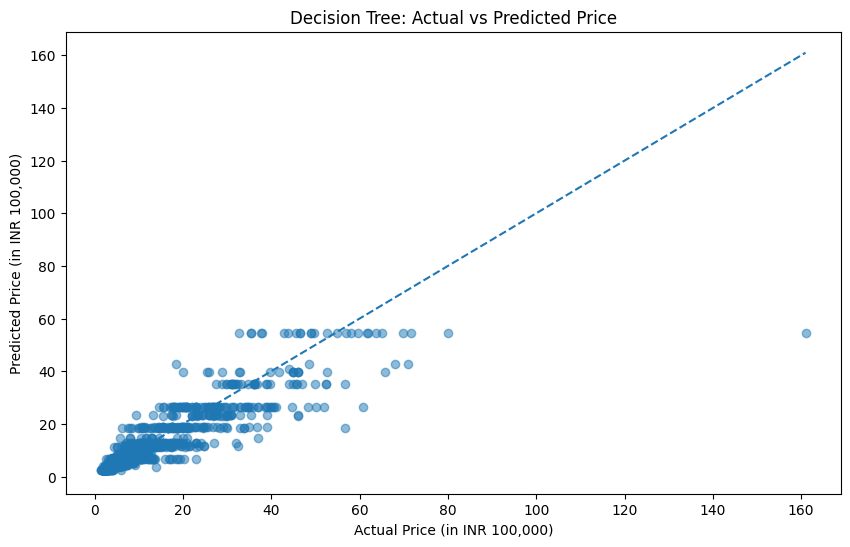

In [ ]:
#Plot actual vs predicted price

#We used Price_log, so must account for log transformation
test_predictions_exp = np.exp(dt_test_predictions)
test_observed_exp = np.exp(y_test)

plt.figure(figsize=(10, 6))

plt.scatter(test_observed_exp, test_predictions_exp, alpha=0.5)
plt.plot([test_observed_exp.min(), test_observed_exp.max()], [test_observed_exp.min(), test_observed_exp.max()], '--')

plt.xlabel('Actual Price (in INR 100,000)')
plt.ylabel('Predicted Price (in INR 100,000)')
plt.title('Decision Tree: Actual vs Predicted Price')
plt.show()

Observations:

- When looking into different depths we could use for the decision tree, we identified the optimal depth of the tree is 5, where the error value is similar for test and train data. After this point, the model will overfit the train dataset (low bias, high variance), but not significantly improve the prediction on the test dataset.
- The decision tree model performs well, with a high R2 value (0.864) and low RMSE/MSE/MAE values, but not as well as the OLS or ridge models.
- When observing the decision tree, we can see the first split is based on Power, if the value is greater than or less than equal to 133, followed by Year.
- Pruning is not needed because we know the optimal depth has been selected and we can see from the tree that each branch leads to two values.
- Finally, the scatterplot shows us how decision trees tend to average multiple data point together, which appears as lines on the graph. This is normal and expected for one decision tree.
- Interestingly, this model begins to plateau around INR 6,000,000, despite observed price points increasing, suggesting the model cannot predict higher priced used cars very well.
- Next, we will utilise random forest model, an ensemble algorithm which uses multiple decision trees, to improve the model's performance.

### **Hyperparameter Tuning: Random Forest**

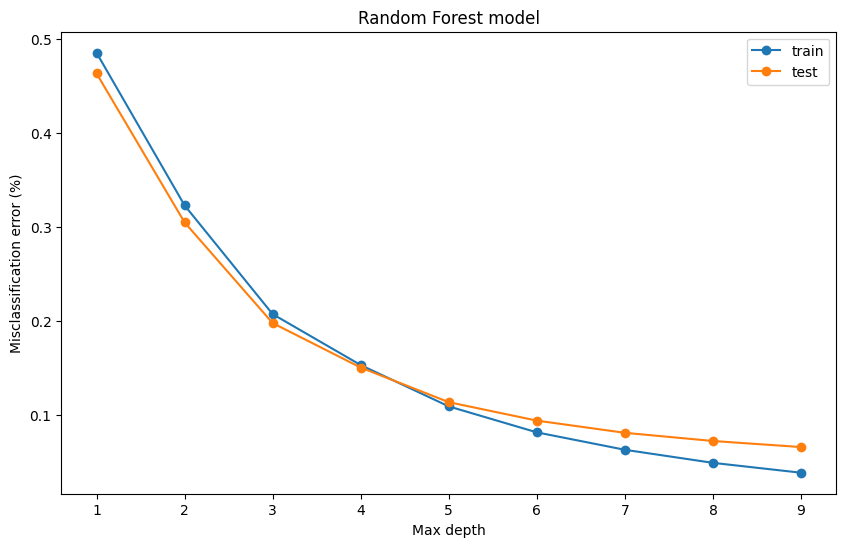

In [ ]:
#Non-linear regression modeling - random forests
from sklearn.ensemble import RandomForestRegressor

#Loop to find optimal depth of tree for the model
train_scores = []
test_scores = []

for depth in range(1, 10):
    rf_regressor = RandomForestRegressor(
        n_estimators = 100,
        max_depth=depth,
        random_state=14)

    #Fit the model
    rf_regressor.fit(X_train, y_train)

    #Obtain misclassification error
    train_scores.append(1- rf_regressor.score(X_train, y_train))
    test_scores.append(1- rf_regressor.score(X_test, y_test))

#Plot graph
plt.plot(range(1, 10), train_scores, '-o', label='train')
plt.plot(range(1, 10), test_scores, '-o', label='test')

plt.legend(loc='best')
plt.xlabel('Max depth')
plt.ylabel('Misclassification error (%)')
plt.title('Random Forest model')
fig = plt.gcf()
fig.set_size_inches(10, 6)
plt.show()

In [ ]:
#Use max_depth=5 for final model
rf_regressor = RandomForestRegressor(n_estimators = 100, max_depth = 5, random_state = 14)
rf_regressor.fit(X_train, y_train)

#Predict using Random Forest regression model
rf_train_predictions = rf_regressor.predict(X_train)
rf_test_predictions = rf_regressor.predict(X_test)

#Check model metrics
rf_metrics = model_metrics('Random Forest',
                            y_train,
                            rf_train_predictions,
                            y_test,
                            rf_test_predictions)


Random Forest
  Dataset      R²     MAE     MSE    RMSE
0   Train  0.8910  0.1819  0.0605  0.2459
1    Test  0.8865  0.1921  0.0646  0.2541


**Feature Importance**

In [ ]:
#Find most important features
rf_importance = pd.Series(rf_regressor.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print(rf_importance.head())

Power                    0.722286
Year                     0.216139
Engine                   0.029462
Kilometers_Driven_log    0.006211
Brand_Land Rover         0.005147
dtype: float64


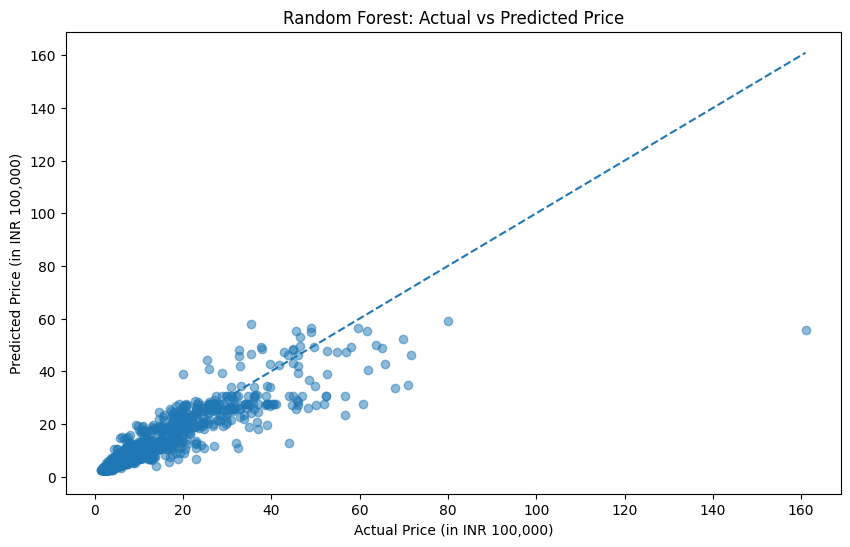

In [ ]:
#Plot actual vs predicted price

#We used Price_log, so must account for log transformation
test_predictions_exp = np.exp(rf_test_predictions)
test_observed_exp = np.exp(y_test)

plt.figure(figsize=(10, 6))

plt.scatter(test_observed_exp, test_predictions_exp, alpha=0.5)
plt.plot([test_observed_exp.min(), test_observed_exp.max()], [test_observed_exp.min(), test_observed_exp.max()], '--')

plt.xlabel('Actual Price (in INR 100,000)')
plt.ylabel('Predicted Price (in INR 100,000)')
plt.title('Random Forest: Actual vs Predicted Price')
plt.show()

Observations:

- For the random forest model, we selected the default number of estimators (100 trees) and found the ideal depth of each tree should be 5.
- The random forest model performs well, with a high R2 value (0.886) and low RMSE/MSE/MAE values.
- It performs slightly better than a single decision tree, which is expected since it's using 100 trees and averaging the prediction from each tree, but not as well as the OLS or ridge models.
- Similar to the single decision tree model, this model begins to plateau around INR 6,000,000, despite observed price points increasing. This suggests the model cannot predict higher priced used cars very well.
- Similar to the other models, Power and Year are the most important features for the model's prediction.


## **Conclusions and Recommendations**

**1. Comparison of various techniques and their relative performance based on chosen Metric (Measure of success):**


- We performed four different types of regression algorithms and evaluated the models' performance using R2 value, RMSE, MSE and MAE.
- The linear regression models - OLS and Ridge - performed better than the non-linear regression models - Decision Tree and Random Forest. This suggests the relationship between Price and its' features are more linear than non-linear.
- The OLS Model 3 had the best performance, with a R2 value of 0.931 for the test dataset and a similar value of 0.924 for the train dataset. We checked and statisfied most of the assumptions of a linear regression model and confirmed the OLS model was not overfitting or underfitting the data.
- Unfortunately, heteroscedasticity was present in the OLS model. This is likely because the majority of the dataset consists of used car prices below INR 4,000,000, with few observations exceeding this price. From EDA, we know the median used car price was INR 564,000. This causes an uneven spread in the residuals as price increases and leads to greater variability across the higher price points.
- The single decision tree was useful to look closer into the top two features that influence used car price - Power and Year. The tree showed us that an engine either above or below 133 BHP is the most influential split of the data, with cars manufactured either before 2011 or after 2012 being the next most influential split.
- Although decisions trees are easy to understand and can shed more light into patterns in the data, they tend to overfit the data and do not predict individual points well.
- Random forests are better than single decision trees, but in our analysis, they still did not perform better than traditional linear regression algorithms.

**2. Refined insights:**

- The power of the engine and year the car was manufactured are the top two most influential features that help predict used car prices.
- Given the dataset had used car prices mostly below INR 4,000,000, the model can predict prices of used cars below this thresold very well, with variability seen above this threshold. More data points on higher priced used cars would help improve prediction performance.
- The price of a new car of the same model may have helped better predict the price of used cars, since with the few data points we had, there was a clear linear relationship between these variables. However, without sufficient data from this variable to include within our modeling algorithms, we cannot say for certain if new car price could help predict used car price.


**3. Proposal for the final solution design:**


- My recommendation to Cars4U is to use OLS Model 3. The equation is as follows:

log(Price) = 0.4202 + 1.997(Year) - 0.401(Mileage) + 0.776(Engine) + 2.192(Power) + 0.291(Seats) - 0.544(Kilometers_Driven_log) + 0.142(Location_Bangalore) + 0.020(Location_Chennai) + 0.102(Location_Coimbatore) - 0.042(Location_Delhi) + 0.093(Location_Hyderabad) - 0.026(Location_Jaipur) - 0.015(Location_Kochi) - 0.194(Location_Kolkata) - 0.030(Location_Mumbai) - 0.017(Location_Pune) + 0.235(Fuel_Type_Diesel) + 0.950(Fuel_Type_Electric) - 0.014(Fuel_Type_LPG) - 0.101(Transmission_Manual) - 0.028(Owner_Type_Fourth & Above) - 0.048(Owner_Type_Second) - 0.066(Owner_Type_Third) + 0.577(Brand_Audi) + 0.537(Brand_BMW) + 0.280(Brand_Bentley) - 0.243(Brand_Chevrolet) - 0.406(Brand_Datsun) - 0.219(Brand_Fiat) + 0.113(Brand_Force) - 0.056(Brand_Ford) + 0.028(Brand_Honda) - 0.011(Brand_Hyundai) - 0.172(Brand_Isuzu) + 0.603(Brand_Jaguar) + 0.222(Brand_Jeep) + 0.705(Brand_Lamborghini) + 0.837(Brand_Land Rover) - 0.134(Brand_Mahindra) + 0.590(Brand_Mercedes-Benz) + 0.975(Brand_Mini) + 0.223(Brand_Mitsubishi) - 0.049(Brand_Nissan) + 0.411(Brand_Porsche) - 0.072(Brand_Renault) + 0.052(Brand_Skoda) - 0.016(Brand_Smart) - 0.389(Brand_Tata) + 0.179(Brand_Toyota) - 0.037(Brand_Volkswagen) + 0.388(Brand_Volvo)

- This model statisfies most linear regression assumptions, accounts for multicollinearity and outperforms other OLS models, as well as ridge, decision tree and random forest algorithms.
- The model can reliably predict used car prices, with some variability seen with higher priced cars. However, given that most used cars are priced below INR 4,000,000, the model fits the purpose of Cars4U.